<a href="https://colab.research.google.com/github/Ganasa18/belajar-tensorflow/blob/main/train_class_prompt_labeling_v3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# =========================================================
# CELL 1 — GOOGLE DRIVE + TRAINING PATH SETUP
# ROUTER V2 MODEL TRAINING
# =========================================================

from google.colab import drive

import os


# =========================================================
# 1. MOUNT GOOGLE DRIVE
# =========================================================

DRIVE_MOUNT = "/content/drive"

drive.mount(
    DRIVE_MOUNT,
    force_remount=False
)

assert os.path.exists(
    f"{DRIVE_MOUNT}/MyDrive"
), "Google Drive belum mounted"


# =========================================================
# 2. STORAGE DIRECTORY
# =========================================================

SAVE_DIR = (
    f"{DRIVE_MOUNT}/MyDrive/router_classifier"
)

os.makedirs(
    SAVE_DIR,
    exist_ok=True
)


# =========================================================
# 3. DATASET PATHS
# =========================================================

CLEAN_TRAIN_PATH = (
    f"{SAVE_DIR}/router_v2_clean_train.csv"
)

REVIEW_SAMPLES_PATH = (
    f"{SAVE_DIR}/router_v2_review_samples.csv"
)


# =========================================================
# 4. MODEL OUTPUT PATHS
# =========================================================

MODEL_PATH = (
    f"{SAVE_DIR}/router_v2_classifier.joblib"
)

BEST_MODEL_PATH = (
    f"{SAVE_DIR}/router_v2_classifier_best.joblib"
)

METRICS_PATH = (
    f"{SAVE_DIR}/router_v2_training_metrics.json"
)

PREDICTIONS_PATH = (
    f"{SAVE_DIR}/router_v2_test_predictions.csv"
)

ERROR_ANALYSIS_PATH = (
    f"{SAVE_DIR}/router_v2_error_analysis.csv"
)


# =========================================================
# 5. VALIDATION
# =========================================================

if not os.path.exists(CLEAN_TRAIN_PATH):

    raise FileNotFoundError(
        f"Clean dataset tidak ditemukan:\n"
        f"{CLEAN_TRAIN_PATH}"
    )


# =========================================================
# 6. STATUS
# =========================================================

print()
print("=" * 70)
print("ROUTER V2 — MODEL TRAINING STORAGE")
print("=" * 70)

print(
    "SAVE_DIR       :",
    SAVE_DIR
)

print(
    "Clean dataset  :",
    CLEAN_TRAIN_PATH
)

print(
    "Review samples :",
    REVIEW_SAMPLES_PATH
)

print(
    "Model output   :",
    MODEL_PATH
)

print(
    "Best model     :",
    BEST_MODEL_PATH
)

print(
    "Metrics        :",
    METRICS_PATH
)

print("=" * 70)

Mounted at /content/drive

ROUTER V2 — MODEL TRAINING STORAGE
SAVE_DIR       : /content/drive/MyDrive/router_classifier
Clean dataset  : /content/drive/MyDrive/router_classifier/router_v2_clean_train.csv
Review samples : /content/drive/MyDrive/router_classifier/router_v2_review_samples.csv
Model output   : /content/drive/MyDrive/router_classifier/router_v2_classifier.joblib
Best model     : /content/drive/MyDrive/router_classifier/router_v2_classifier_best.joblib
Metrics        : /content/drive/MyDrive/router_classifier/router_v2_training_metrics.json


In [2]:
# =========================================================
# CELL 2 — ROUTING TAXONOMY
# ROUTER V2 MODEL TRAINING
# =========================================================

LABELS = [
    "SIMPLE",
    "GENERAL",
    "REASONING",
    "CODING_SIMPLE",
    "CODING_COMPLEX",
    "TRANSFORM",
    "CREATIVE",
]


CATEGORY_DESCRIPTIONS = {

    "SIMPLE":
        "Simple factual questions, definitions, easy lookup, "
        "basic calculations, or very short tasks requiring "
        "little to no reasoning.",

    "GENERAL":
        "Normal assistant questions and explanations that "
        "require some understanding but do not require "
        "substantial multi-step reasoning, comparison, "
        "planning, or software engineering analysis.",

    "REASONING":
        "Non-coding analytical tasks requiring comparison, "
        "planning, trade-offs, deduction, mathematics, "
        "decision making, or multi-step reasoning. "
        "Technology comparisons without actual software "
        "debugging or implementation belong here.",

    "CODING_SIMPLE":
        "Small programming tasks such as regex, SQL, syntax "
        "correction, short scripts, small functions, simple "
        "code modification, or straightforward implementation.",

    "CODING_COMPLEX":
        "Software engineering tasks requiring substantial "
        "technical reasoning involving debugging, architecture, "
        "security, concurrency, performance, databases, "
        "distributed systems, backend/frontend systems, "
        "or multi-component implementation.",

    "TRANSFORM":
        "Tasks whose main purpose is transforming existing "
        "user-provided content, including translation, "
        "summarization, rewriting, extraction, formatting, "
        "shortening, restructuring, or conversion.",

    "CREATIVE":
        "Creative generation and ideation such as stories, "
        "dialogue, slogans, names, concepts, fictional content, "
        "brainstorming, characters, scenarios, "
        "or creative variations.",
}


# =========================================================
# VALIDATE TAXONOMY
# =========================================================

for label in LABELS:

    if label not in CATEGORY_DESCRIPTIONS:

        raise ValueError(
            f"Missing description: {label}"
        )


print()
print("=" * 70)
print("ROUTING TAXONOMY")
print("=" * 70)

for i, label in enumerate(
    LABELS,
    start=1
):

    print(
        f"{i}. {label}"
    )

print()
print(
    "Total labels:",
    len(LABELS)
)

print("=" * 70)


ROUTING TAXONOMY
1. SIMPLE
2. GENERAL
3. REASONING
4. CODING_SIMPLE
5. CODING_COMPLEX
6. TRANSFORM
7. CREATIVE

Total labels: 7


In [3]:
# =========================================================
# CELL 3 — LOAD + AUTO-DETECT DATASET COLUMNS
# ROUTER V2 MODEL TRAINING
# =========================================================

import pandas as pd


# =========================================================
# LOAD
# =========================================================

df = pd.read_csv(
    CLEAN_TRAIN_PATH
)


# =========================================================
# COLUMN DETECTION
# =========================================================

print()
print("=" * 70)
print("DATASET COLUMNS")
print("=" * 70)

print(
    list(df.columns)
)


# Kandidat nama kolom prompt/text
TEXT_CANDIDATES = [
    "text",
    "prompt",
    "request",
    "user_prompt",
    "query",
    "input",
    "content",
]

LABEL_CANDIDATES = [
    "label",
    "target",
    "category",
    "route",
]


TEXT_COLUMN = None
LABEL_COLUMN = None


for col in TEXT_CANDIDATES:

    if col in df.columns:

        TEXT_COLUMN = col
        break


for col in LABEL_CANDIDATES:

    if col in df.columns:

        LABEL_COLUMN = col
        break


# =========================================================
# VALIDATION
# =========================================================

if TEXT_COLUMN is None:

    raise ValueError(
        "Tidak bisa menemukan kolom prompt/text.\n"
        f"Kolom tersedia: {list(df.columns)}"
    )


if LABEL_COLUMN is None:

    raise ValueError(
        "Tidak bisa menemukan kolom label.\n"
        f"Kolom tersedia: {list(df.columns)}"
    )


print()
print(
    "Detected text column :",
    TEXT_COLUMN
)

print(
    "Detected label column:",
    LABEL_COLUMN
)


# =========================================================
# STANDARDIZE COLUMN NAMES
#
# Mulai dari sini semua cell selalu pakai:
# text
# label
# =========================================================

if TEXT_COLUMN != "text":

    df = df.rename(
        columns={
            TEXT_COLUMN: "text"
        }
    )


if LABEL_COLUMN != "label":

    df = df.rename(
        columns={
            LABEL_COLUMN: "label"
        }
    )


# =========================================================
# BASIC INFO
# =========================================================

print()
print("=" * 70)
print("CLEAN DATASET INSPECTION")
print("=" * 70)

print(
    "Shape:",
    df.shape
)

print()

print(
    "Standardized columns:",
    list(df.columns)
)

print()

display(
    df.head(10)
)


# =========================================================
# DISTRIBUTION
# =========================================================

print()
print("=" * 70)
print("LABEL DISTRIBUTION")
print("=" * 70)

distribution = (
    df["label"]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

print(
    distribution
)

print()

print(
    "Total:",
    len(df)
)


# =========================================================
# NULL CHECK
# =========================================================

print()
print("=" * 70)
print("NULL CHECK")
print("=" * 70)

print(
    df[
        [
            "text",
            "label"
        ]
    ]
    .isna()
    .sum()
)


print()
print("=" * 70)
print("CELL 3 COMPLETE")
print("=" * 70)


DATASET COLUMNS
['prompt', 'label']

Detected text column : prompt
Detected label column: label

CLEAN DATASET INSPECTION
Shape: (327, 2)

Standardized columns: ['text', 'label']



,text,label
0,Beri saya pertanyaan untuk ditanyakan kepada s...,CREATIVE
1,Jelaskan seperti apa hari-hari musim panas pad...,GENERAL
2,Tulis ulang kalimat berikut untuk mendapatkan ...,TRANSFORM
3,Tuliskan sebuah cerita tentang seorang wanita ...,CREATIVE
4,Jelaskan kasus penggunaan potensial untuk tekn...,GENERAL
5,Buatlah masalah yang dapat diselesaikan dengan...,CREATIVE
6,Hasilkan laporan yang merangkum temuan utama m...,TRANSFORM
7,Buatlah contoh dua orang sedang berbincang ten...,CREATIVE
8,"Buatlah puisi pendek dengan kata “bunga”, “war...",CREATIVE
9,Berikan dua contoh situasi di mana Anda mengha...,GENERAL



LABEL DISTRIBUTION
label
SIMPLE            39
GENERAL           55
REASONING         37
CODING_SIMPLE     34
CODING_COMPLEX    87
TRANSFORM         43
CREATIVE          32
Name: count, dtype: int64

Total: 327

NULL CHECK
text     0
label    0
dtype: int64

CELL 3 COMPLETE


In [4]:
# =========================================================
# CELL 4 — DATA QUALITY CLEANUP
# ROUTER V2 MODEL TRAINING
# =========================================================

import pandas as pd


# =========================================================
# COPY WORKING DATAFRAME
# =========================================================

df_clean = df.copy()


# =========================================================
# NORMALIZE LABEL
# =========================================================

df_clean["label"] = (
    df_clean["label"]
    .astype(str)
    .str.strip()
    .str.upper()
)


# =========================================================
# NORMALIZE TEXT
# =========================================================

df_clean["text"] = (
    df_clean["text"]
    .fillna("")
    .astype(str)
    .str.strip()
)


# =========================================================
# REMOVE EMPTY TEXT
# =========================================================

before_empty = len(df_clean)

df_clean = df_clean[
    df_clean["text"].str.len() > 0
].copy()

removed_empty = (
    before_empty
    - len(df_clean)
)


# =========================================================
# REMOVE INVALID LABELS
# =========================================================

before_invalid = len(df_clean)

df_clean = df_clean[
    df_clean["label"].isin(
        LABELS
    )
].copy()

removed_invalid = (
    before_invalid
    - len(df_clean)
)


# =========================================================
# REMOVE EXACT DUPLICATES
#
# text + label sama persis
# =========================================================

before_duplicates = len(df_clean)

df_clean = (
    df_clean
    .drop_duplicates(
        subset=[
            "text",
            "label"
        ],
        keep="first"
    )
    .reset_index(
        drop=True
    )
)

removed_duplicates = (
    before_duplicates
    - len(df_clean)
)


# =========================================================
# CONFLICT CHECK
#
# text sama tetapi label berbeda
# jangan otomatis dibuang
# =========================================================

conflict_counts = (
    df_clean
    .groupby("text")["label"]
    .nunique()
)

conflicting_texts = (
    conflict_counts[
        conflict_counts > 1
    ]
    .index
    .tolist()
)


# =========================================================
# FINAL DISTRIBUTION
# =========================================================

distribution = (
    df_clean["label"]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)


# =========================================================
# STATUS
# =========================================================

print()
print("=" * 70)
print("DATA QUALITY CLEANUP")
print("=" * 70)

print(
    "Original samples        :",
    len(df)
)

print(
    "Removed empty text      :",
    removed_empty
)

print(
    "Removed invalid labels  :",
    removed_invalid
)

print(
    "Removed exact duplicates:",
    removed_duplicates
)

print(
    "Remaining conflicts     :",
    len(conflicting_texts)
)

print(
    "Final samples           :",
    len(df_clean)
)

print()

print(
    "Final distribution:"
)

print(
    distribution
)

print("=" * 70)


# =========================================================
# SAFETY CHECKS
# =========================================================

missing_labels = [
    label
    for label in LABELS
    if distribution[label] == 0
]

if missing_labels:

    raise RuntimeError(
        "Ada label yang kehilangan seluruh sample: "
        + ", ".join(
            missing_labels
        )
    )


if conflicting_texts:

    print()
    print(
        "WARNING: ditemukan text yang memiliki "
        "lebih dari satu label."
    )

    display(
        df_clean[
            df_clean["text"].isin(
                conflicting_texts
            )
        ]
        .sort_values(
            "text"
        )
        .head(50)
    )

else:

    print()
    print(
        "PASS — tidak ada conflicting labels."
    )


print()
print("=" * 70)
print("CELL 4 COMPLETE")
print("=" * 70)


DATA QUALITY CLEANUP
Original samples        : 327
Removed empty text      : 0
Removed invalid labels  : 0
Removed exact duplicates: 0
Remaining conflicts     : 0
Final samples           : 327

Final distribution:
label
SIMPLE            39
GENERAL           55
REASONING         37
CODING_SIMPLE     34
CODING_COMPLEX    87
TRANSFORM         43
CREATIVE          32
Name: count, dtype: int64

PASS — tidak ada conflicting labels.

CELL 4 COMPLETE


In [5]:
# =========================================================
# CELL 5 — STRATIFIED TRAIN / TEST SPLIT
# ROUTER V2 MODEL TRAINING
# =========================================================

from sklearn.model_selection import train_test_split


# =========================================================
# FEATURES + TARGET
# =========================================================

X = df_clean["text"].copy()
y = df_clean["label"].copy()


# =========================================================
# STRATIFIED SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)


# =========================================================
# STATUS
# =========================================================

print()
print("=" * 70)
print("TRAIN / TEST SPLIT")
print("=" * 70)

print("Total samples :", len(df_clean))
print("Train samples :", len(X_train))
print("Test samples  :", len(X_test))

print()
print("TRAIN DISTRIBUTION")
print(
    y_train
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

print()
print("TEST DISTRIBUTION")
print(
    y_test
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

print("=" * 70)


# =========================================================
# SAFETY CHECK
# =========================================================

assert set(y_train.unique()) == set(LABELS), (
    "Train set kehilangan label."
)

assert set(y_test.unique()) == set(LABELS), (
    "Test set kehilangan label."
)

print()
print("PASS — semua label ada di train dan test.")


TRAIN / TEST SPLIT
Total samples : 327
Train samples : 261
Test samples  : 66

TRAIN DISTRIBUTION
label
SIMPLE            31
GENERAL           44
REASONING         30
CODING_SIMPLE     27
CODING_COMPLEX    69
TRANSFORM         34
CREATIVE          26
Name: count, dtype: int64

TEST DISTRIBUTION
label
SIMPLE             8
GENERAL           11
REASONING          7
CODING_SIMPLE      7
CODING_COMPLEX    18
TRANSFORM          9
CREATIVE           6
Name: count, dtype: int64

PASS — semua label ada di train dan test.


In [6]:
# =========================================================
# CELL 6 — BASELINE MODEL
# TF-IDF + LOGISTIC REGRESSION
# =========================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression


# =========================================================
# MODEL
# =========================================================

baseline_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=1,
                max_df=0.98,
                max_features=20000,
                sublinear_tf=True,
            )
        ),

        (
            "classifier",
            LogisticRegression(
                C=2.0,
                max_iter=3000,
                class_weight="balanced",
                random_state=42,
            )
        ),
    ]
)


# =========================================================
# TRAIN
# =========================================================

print()
print("=" * 70)
print("TRAIN BASELINE MODEL")
print("=" * 70)

baseline_model.fit(
    X_train,
    y_train
)

print("Training complete.")

print("=" * 70)


TRAIN BASELINE MODEL
Training complete.


In [7]:
# =========================================================
# CELL 7 — BASELINE EVALUATION
# ROUTER V2 MODEL TRAINING
# =========================================================

import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
)


# =========================================================
# PREDICT
# =========================================================

y_pred = baseline_model.predict(
    X_test
)


# =========================================================
# PROBABILITY / CONFIDENCE
# =========================================================

y_proba = baseline_model.predict_proba(
    X_test
)

confidence = np.max(
    y_proba,
    axis=1
)


# =========================================================
# METRICS
# =========================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_test,
    y_pred,
    average="weighted",
    zero_division=0
)

macro_precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)


# =========================================================
# DISPLAY
# =========================================================

print()
print("=" * 70)
print("BASELINE RESULTS")
print("=" * 70)

print(f"Accuracy        : {accuracy:.4f}")
print(f"Macro F1        : {macro_f1:.4f}")
print(f"Weighted F1     : {weighted_f1:.4f}")
print(f"Macro Precision : {macro_precision:.4f}")
print(f"Macro Recall    : {macro_recall:.4f}")

print()
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        y_pred,
        labels=LABELS,
        digits=4,
        zero_division=0
    )
)


# =========================================================
# RESULT DATAFRAME
# =========================================================

prediction_df = pd.DataFrame(
    {
        "text": X_test.values,
        "true_label": y_test.values,
        "pred_label": y_pred,
        "confidence": confidence,
    }
)

prediction_df["correct"] = (
    prediction_df["true_label"]
    == prediction_df["pred_label"]
)

print()
print(
    "Correct:",
    int(
        prediction_df["correct"].sum()
    ),
    "/",
    len(prediction_df)
)


BASELINE RESULTS
Accuracy        : 0.7879
Macro F1        : 0.7415
Weighted F1     : 0.7629
Macro Precision : 0.7488
Macro Recall    : 0.7555

CLASSIFICATION REPORT
                precision    recall  f1-score   support

        SIMPLE     0.3333    0.1250    0.1818         8
       GENERAL     0.7273    0.7273    0.7273        11
     REASONING     0.6667    0.8571    0.7500         7
 CODING_SIMPLE     0.8571    0.8571    0.8571         7
CODING_COMPLEX     0.8571    1.0000    0.9231        18
     TRANSFORM     0.8000    0.8889    0.8421         9
      CREATIVE     1.0000    0.8333    0.9091         6

      accuracy                         0.7879        66
     macro avg     0.7488    0.7555    0.7415        66
  weighted avg     0.7570    0.7879    0.7629        66


Correct: 52 / 66


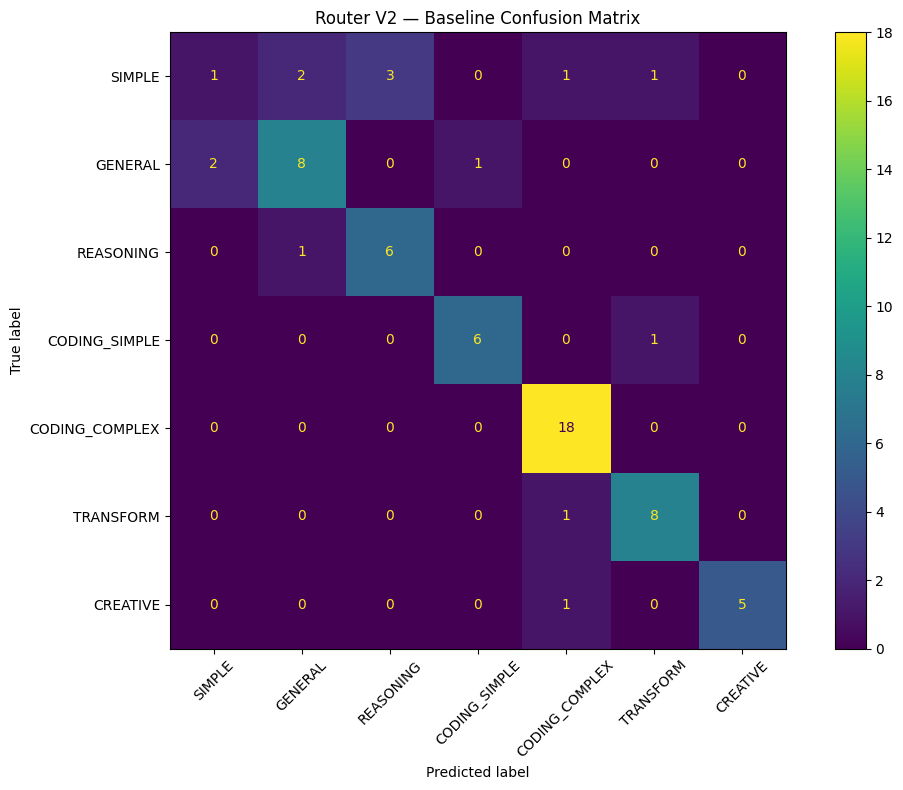


HIGH CONFIDENCE WRONG PREDICTIONS


,true_label,pred_label,confidence,text
39,SIMPLE,GENERAL,0.490044,Apa contoh karbohidrat kompleks?
25,REASONING,GENERAL,0.374743,Apa perbedaan antara synchronous dan asynchron...
5,GENERAL,SIMPLE,0.312566,Apa itu syntax dasar loop di Ruby?
0,CODING_SIMPLE,TRANSFORM,0.309728,"Hapus duplikat daftar berikut.\nangka = [1, 4,..."
44,GENERAL,CODING_SIMPLE,0.297097,Help me understand how to use map() in JavaScript
18,GENERAL,SIMPLE,0.287076,Apa peran pemerintah dalam perekonomian?
13,SIMPLE,GENERAL,0.267669,Hari apa setelah Jumat?
20,SIMPLE,CODING_COMPLEX,0.264809,Who wrote 'Romeo and Juliet'?
6,SIMPLE,REASONING,0.223364,Tulis persamaan untuk menghitung total biaya s...
40,SIMPLE,REASONING,0.219552,Who wrote the play 'Romeo and Juliet'?



LOW CONFIDENCE SAMPLES


,true_label,pred_label,confidence,correct,text
61,SIMPLE,REASONING,0.175910,False,When was the Declaration of Independence signed?
62,CREATIVE,CODING_COMPLEX,0.182604,False,Come up with a catchy slogan for a reusable co...
54,GENERAL,GENERAL,0.192447,True,Jelaskan kualitas seorang manajer proyek yang ...
34,SIMPLE,TRANSFORM,0.192801,False,List the three primary colors.
11,CREATIVE,CREATIVE,0.194918,True,Buatkan karakter fiksi utama untuk novel komed...
17,TRANSFORM,CODING_COMPLEX,0.207221,False,Extract the main arguments from the following ...
64,CREATIVE,CREATIVE,0.209812,True,Buatlah masalah yang dapat diselesaikan dengan...
59,TRANSFORM,TRANSFORM,0.214307,True,Extract all email addresses from this text
65,CODING_COMPLEX,CODING_COMPLEX,0.216522,True,Bagaimana mengimplementasikan load balancer be...
40,SIMPLE,REASONING,0.219552,False,Who wrote the play 'Romeo and Juliet'?



TOP CONFUSION PAIRS


,true_label,pred_label,count
7,SIMPLE,REASONING,3
3,GENERAL,SIMPLE,2
6,SIMPLE,GENERAL,2
0,CODING_SIMPLE,TRANSFORM,1
1,CREATIVE,CODING_COMPLEX,1
2,GENERAL,CODING_SIMPLE,1
5,SIMPLE,CODING_COMPLEX,1
4,REASONING,GENERAL,1
8,SIMPLE,TRANSFORM,1
9,TRANSFORM,CODING_COMPLEX,1



CELL 8 COMPLETE
Predictions saved: /content/drive/MyDrive/router_classifier/router_v2_test_predictions.csv
Errors saved     : /content/drive/MyDrive/router_classifier/router_v2_error_analysis.csv


In [8]:
# =========================================================
# CELL 8 — CONFUSION MATRIX + ERROR ANALYSIS
# ROUTER V2 MODEL TRAINING
# =========================================================

import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
)


# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    y_pred,
    labels=LABELS
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=LABELS
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    "Router V2 — Baseline Confusion Matrix"
)

plt.tight_layout()
plt.show()


# =========================================================
# WRONG PREDICTIONS
# =========================================================

wrong_df = (
    prediction_df[
        prediction_df["correct"] == False
    ]
    .copy()
)


# =========================================================
# HIGH CONFIDENCE WRONG
#
# Ini paling penting:
# model salah tapi yakin.
# =========================================================

high_conf_wrong = (
    wrong_df
    .sort_values(
        "confidence",
        ascending=False
    )
)


print()
print("=" * 70)
print("HIGH CONFIDENCE WRONG PREDICTIONS")
print("=" * 70)

display(
    high_conf_wrong[
        [
            "true_label",
            "pred_label",
            "confidence",
            "text",
        ]
    ]
    .head(30)
)


# =========================================================
# LOW CONFIDENCE SAMPLES
# =========================================================

low_confidence_df = (
    prediction_df
    .sort_values(
        "confidence",
        ascending=True
    )
)


print()
print("=" * 70)
print("LOW CONFIDENCE SAMPLES")
print("=" * 70)

display(
    low_confidence_df[
        [
            "true_label",
            "pred_label",
            "confidence",
            "correct",
            "text",
        ]
    ]
    .head(30)
)


# =========================================================
# CONFUSION PAIRS
# =========================================================

confusion_pairs = (
    wrong_df
    .groupby(
        [
            "true_label",
            "pred_label"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)


print()
print("=" * 70)
print("TOP CONFUSION PAIRS")
print("=" * 70)

display(
    confusion_pairs
)


# =========================================================
# SAVE PREDICTIONS
# =========================================================

prediction_df.to_csv(
    PREDICTIONS_PATH,
    index=False
)

wrong_df.to_csv(
    ERROR_ANALYSIS_PATH,
    index=False
)

print()
print("=" * 70)
print("CELL 8 COMPLETE")
print("=" * 70)

print(
    "Predictions saved:",
    PREDICTIONS_PATH
)

print(
    "Errors saved     :",
    ERROR_ANALYSIS_PATH
)

print("=" * 70)

In [9]:
# =========================================================
# CELL 9 — SIMPLE ERROR ANALYSIS
# ROUTER V2 MODEL TRAINING
# =========================================================

simple_errors = prediction_df[
    (
        (prediction_df["true_label"] == "SIMPLE")
        |
        (prediction_df["pred_label"] == "SIMPLE")
    )
].copy()

simple_errors = simple_errors.sort_values(
    [
        "correct",
        "confidence"
    ],
    ascending=[
        True,
        False
    ]
)

print()
print("=" * 70)
print("SIMPLE ERROR ANALYSIS")
print("=" * 70)

display(
    simple_errors[
        [
            "true_label",
            "pred_label",
            "confidence",
            "correct",
            "text"
        ]
    ]
)

print()
print("True SIMPLE samples:")
print(
    (prediction_df["true_label"] == "SIMPLE").sum()
)

print(
    "Correct SIMPLE:",
    (
        (prediction_df["true_label"] == "SIMPLE")
        &
        (prediction_df["pred_label"] == "SIMPLE")
    ).sum()
)


SIMPLE ERROR ANALYSIS


,true_label,pred_label,confidence,correct,text
39,SIMPLE,GENERAL,0.490044,False,Apa contoh karbohidrat kompleks?
5,GENERAL,SIMPLE,0.312566,False,Apa itu syntax dasar loop di Ruby?
18,GENERAL,SIMPLE,0.287076,False,Apa peran pemerintah dalam perekonomian?
13,SIMPLE,GENERAL,0.267669,False,Hari apa setelah Jumat?
20,SIMPLE,CODING_COMPLEX,0.264809,False,Who wrote 'Romeo and Juliet'?
6,SIMPLE,REASONING,0.223364,False,Tulis persamaan untuk menghitung total biaya s...
40,SIMPLE,REASONING,0.219552,False,Who wrote the play 'Romeo and Juliet'?
34,SIMPLE,TRANSFORM,0.192801,False,List the three primary colors.
61,SIMPLE,REASONING,0.175910,False,When was the Declaration of Independence signed?
56,SIMPLE,SIMPLE,0.439467,True,Berapa jumlah provinsi di Indonesia?



True SIMPLE samples:
8
Correct SIMPLE: 1


In [10]:
# =========================================================
# CELL 10 — CONFUSION PAIRS ANALYSIS
# ROUTER V2 MODEL TRAINING
# =========================================================

wrong_df = prediction_df[
    prediction_df["correct"] == False
].copy()

confusion_pairs = (
    wrong_df
    .groupby(
        [
            "true_label",
            "pred_label"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

print()
print("=" * 70)
print("TOP CONFUSION PAIRS")
print("=" * 70)

display(
    confusion_pairs
)

print()
print("=" * 70)
print("SIMPLE CONFUSION ONLY")
print("=" * 70)

simple_confusions = confusion_pairs[
    (
        (confusion_pairs["true_label"] == "SIMPLE")
        |
        (confusion_pairs["pred_label"] == "SIMPLE")
    )
]

display(
    simple_confusions
)


TOP CONFUSION PAIRS


,true_label,pred_label,count
7,SIMPLE,REASONING,3
3,GENERAL,SIMPLE,2
6,SIMPLE,GENERAL,2
0,CODING_SIMPLE,TRANSFORM,1
1,CREATIVE,CODING_COMPLEX,1
2,GENERAL,CODING_SIMPLE,1
5,SIMPLE,CODING_COMPLEX,1
4,REASONING,GENERAL,1
8,SIMPLE,TRANSFORM,1
9,TRANSFORM,CODING_COMPLEX,1



SIMPLE CONFUSION ONLY


,true_label,pred_label,count
7,SIMPLE,REASONING,3
3,GENERAL,SIMPLE,2
6,SIMPLE,GENERAL,2
5,SIMPLE,CODING_COMPLEX,1
8,SIMPLE,TRANSFORM,1


In [11]:
# =========================================================
# CELL 11 — CROSS VALIDATION BASELINE
# ROUTER V2 MODEL TRAINING
# =========================================================

import numpy as np

from sklearn.model_selection import StratifiedKFold
from sklearn.model_selection import cross_validate


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
}


cv_results = cross_validate(
    baseline_model,
    df_clean["text"],
    df_clean["label"],
    cv=cv,
    scoring=scoring,
    n_jobs=-1,
    return_train_score=False
)


print()
print("=" * 70)
print("5-FOLD CROSS VALIDATION")
print("=" * 70)

for metric in scoring.keys():

    scores = cv_results[
        f"test_{metric}"
    ]

    print(
        f"{metric:12} : "
        f"{scores.mean():.4f} "
        f"+/- {scores.std():.4f}"
    )

print("=" * 70)


5-FOLD CROSS VALIDATION
accuracy     : 0.8075 +/- 0.0336
macro_f1     : 0.7819 +/- 0.0410
weighted_f1  : 0.7999 +/- 0.0387


In [12]:
# =========================================================
# CELL 12 — COMPARE LOGISTIC VS LINEAR SVM
# ROUTER V2 MODEL TRAINING
# =========================================================

from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import f1_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer


svm_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=1,
                max_df=0.98,
                max_features=20000,
                sublinear_tf=True,
            )
        ),

        (
            "classifier",
            LinearSVC(
                C=1.0,
                class_weight="balanced",
                random_state=42,
            )
        ),
    ]
)


print()
print("=" * 70)
print("TRAIN LINEAR SVM")
print("=" * 70)

svm_model.fit(
    X_train,
    y_train
)

svm_pred = svm_model.predict(
    X_test
)


svm_accuracy = accuracy_score(
    y_test,
    svm_pred
)

svm_macro_f1 = f1_score(
    y_test,
    svm_pred,
    average="macro",
    zero_division=0
)

svm_weighted_f1 = f1_score(
    y_test,
    svm_pred,
    average="weighted",
    zero_division=0
)


print()
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print()
print("LOGISTIC REGRESSION")
print(
    f"Accuracy    : {accuracy:.4f}"
)
print(
    f"Macro F1    : {macro_f1:.4f}"
)
print(
    f"Weighted F1 : {weighted_f1:.4f}"
)

print()
print("LINEAR SVM")
print(
    f"Accuracy    : {svm_accuracy:.4f}"
)
print(
    f"Macro F1    : {svm_macro_f1:.4f}"
)
print(
    f"Weighted F1 : {svm_weighted_f1:.4f}"
)

print()
print("=" * 70)


TRAIN LINEAR SVM

MODEL COMPARISON

LOGISTIC REGRESSION
Accuracy    : 0.7879
Macro F1    : 0.7415
Weighted F1 : 0.7629

LINEAR SVM
Accuracy    : 0.8182
Macro F1    : 0.7709
Weighted F1 : 0.7922




LINEAR SVM — CLASSIFICATION REPORT
                precision    recall  f1-score   support

        SIMPLE     0.3333    0.1250    0.1818         8
       GENERAL     0.7273    0.7273    0.7273        11
     REASONING     0.7500    0.8571    0.8000         7
 CODING_SIMPLE     0.8571    0.8571    0.8571         7
CODING_COMPLEX     0.9474    1.0000    0.9730        18
     TRANSFORM     0.7500    1.0000    0.8571         9
      CREATIVE     1.0000    1.0000    1.0000         6

      accuracy                         0.8182        66
     macro avg     0.7664    0.7952    0.7709        66
  weighted avg     0.7836    0.8182    0.7922        66



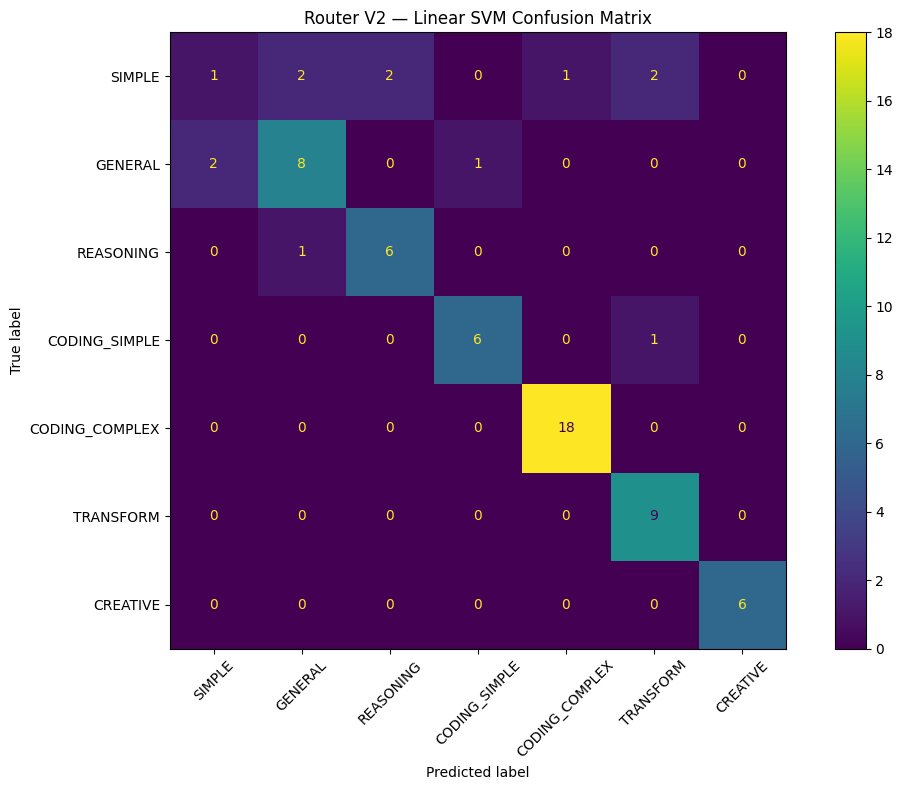


SVM CONFUSION PAIRS


,true_label,pred_label,count
2,GENERAL,SIMPLE,2
7,SIMPLE,TRANSFORM,2
6,SIMPLE,REASONING,2
5,SIMPLE,GENERAL,2
3,REASONING,GENERAL,1
1,GENERAL,CODING_SIMPLE,1
0,CODING_SIMPLE,TRANSFORM,1
4,SIMPLE,CODING_COMPLEX,1


In [13]:
# =========================================================
# CELL 13 — DETAILED SVM EVALUATION
# ROUTER V2 MODEL TRAINING
# =========================================================

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import pandas as pd
import matplotlib.pyplot as plt


print()
print("=" * 70)
print("LINEAR SVM — CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_test,
        svm_pred,
        labels=LABELS,
        digits=4,
        zero_division=0
    )
)


# =========================================================
# RESULT DATAFRAME
# =========================================================

svm_prediction_df = pd.DataFrame(
    {
        "text": X_test.values,
        "true_label": y_test.values,
        "pred_label": svm_pred,
    }
)

svm_prediction_df["correct"] = (
    svm_prediction_df["true_label"]
    == svm_prediction_df["pred_label"]
)


# =========================================================
# CONFUSION MATRIX
# =========================================================

cm = confusion_matrix(
    y_test,
    svm_pred,
    labels=LABELS
)

fig, ax = plt.subplots(
    figsize=(11, 8)
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=LABELS
)

disp.plot(
    ax=ax,
    xticks_rotation=45,
    values_format="d"
)

plt.title(
    "Router V2 — Linear SVM Confusion Matrix"
)

plt.tight_layout()
plt.show()


# =========================================================
# CONFUSION PAIRS
# =========================================================

svm_wrong_df = svm_prediction_df[
    svm_prediction_df["correct"] == False
].copy()

svm_confusions = (
    svm_wrong_df
    .groupby(
        [
            "true_label",
            "pred_label"
        ]
    )
    .size()
    .reset_index(
        name="count"
    )
    .sort_values(
        "count",
        ascending=False
    )
)

print()
print("=" * 70)
print("SVM CONFUSION PAIRS")
print("=" * 70)

display(
    svm_confusions
)

In [14]:
# =========================================================
# CELL 14 — 5-FOLD CROSS VALIDATION FOR SVM
# ROUTER V2 MODEL TRAINING
# =========================================================

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

import numpy as np


cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
}


svm_cv = cross_validate(
    svm_model,
    df_clean["text"],
    df_clean["label"],
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)


print()
print("=" * 70)
print("LINEAR SVM — 5-FOLD CROSS VALIDATION")
print("=" * 70)

svm_cv_summary = {}

for metric in scoring:

    scores = svm_cv[
        f"test_{metric}"
    ]

    mean_score = scores.mean()
    std_score = scores.std()

    svm_cv_summary[metric] = {
        "mean": mean_score,
        "std": std_score
    }

    print(
        f"{metric:12} : "
        f"{mean_score:.4f} "
        f"+/- {std_score:.4f}"
    )

print("=" * 70)


LINEAR SVM — 5-FOLD CROSS VALIDATION
accuracy     : 0.8075 +/- 0.0386
macro_f1     : 0.7819 +/- 0.0455
weighted_f1  : 0.8003 +/- 0.0437


In [15]:
# =========================================================
# CELL 15 — LINEAR SVM C TUNING
# ROUTER V2 MODEL TRAINING
# =========================================================

from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

import pandas as pd
import numpy as np


# =========================================================
# C VALUES
# =========================================================

C_VALUES = [
    0.1,
    0.25,
    0.5,
    0.75,
    1.0,
    1.5,
    2.0,
    3.0,
    5.0,
]


results = []


print()
print("=" * 70)
print("LINEAR SVM — C TUNING")
print("=" * 70)


for c in C_VALUES:

    candidate = Pipeline(
        [
            (
                "tfidf",
                TfidfVectorizer(
                    lowercase=True,
                    ngram_range=(1, 2),
                    min_df=1,
                    max_df=0.98,
                    max_features=20000,
                    sublinear_tf=True,
                )
            ),

            (
                "classifier",
                LinearSVC(
                    C=c,
                    class_weight="balanced",
                    random_state=42,
                )
            ),
        ]
    )


    scores = cross_val_score(
        candidate,
        df_clean["text"],
        df_clean["label"],
        cv=cv,
        scoring="f1_macro",
        n_jobs=-1
    )


    results.append(
        {
            "C": c,
            "macro_f1_mean": scores.mean(),
            "macro_f1_std": scores.std(),
        }
    )


    print(
        f"C={c:<5} "
        f"Macro F1="
        f"{scores.mean():.4f} "
        f"+/- {scores.std():.4f}"
    )


# =========================================================
# RESULTS
# =========================================================

tuning_df = pd.DataFrame(
    results
)

tuning_df = tuning_df.sort_values(
    "macro_f1_mean",
    ascending=False
).reset_index(
    drop=True
)


print()
print("=" * 70)
print("C TUNING RANKING")
print("=" * 70)

display(
    tuning_df
)


BEST_C = float(
    tuning_df.iloc[0]["C"]
)

BEST_CV_MACRO_F1 = float(
    tuning_df.iloc[0]["macro_f1_mean"]
)

print()
print(
    "BEST C:",
    BEST_C
)

print(
    "BEST CV MACRO F1:",
    round(
        BEST_CV_MACRO_F1,
        4
    )
)


LINEAR SVM — C TUNING
C=0.1   Macro F1=0.7776 +/- 0.0356
C=0.25  Macro F1=0.7819 +/- 0.0409
C=0.5   Macro F1=0.7820 +/- 0.0464
C=0.75  Macro F1=0.7788 +/- 0.0464
C=1.0   Macro F1=0.7819 +/- 0.0455
C=1.5   Macro F1=0.7823 +/- 0.0451
C=2.0   Macro F1=0.7823 +/- 0.0451
C=3.0   Macro F1=0.7868 +/- 0.0412
C=5.0   Macro F1=0.7850 +/- 0.0444

C TUNING RANKING


,C,macro_f1_mean,macro_f1_std
0,3.00,0.786799,0.041170
1,5.00,0.785016,0.044434
2,1.50,0.782332,0.045113
3,2.00,0.782332,0.045113
4,0.50,0.782046,0.046411
5,1.00,0.781950,0.045531
6,0.25,0.781917,0.040867
7,0.75,0.778781,0.046397
8,0.10,0.777642,0.035611



BEST C: 3.0
BEST CV MACRO F1: 0.7868


In [17]:
# =========================================================
# CELL 16 — TRAIN BEST SVM CANDIDATE
# ROUTER V2 MODEL TRAINING
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)


best_svm_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=1,
                max_df=0.98,
                max_features=20000,
                sublinear_tf=True,
            )
        ),

        (
            "classifier",
            LinearSVC(
                C=BEST_C,
                class_weight="balanced",
                random_state=42,
            )
        ),
    ]
)


# =========================================================
# TRAIN ON SAME TRAIN SPLIT
# =========================================================

best_svm_model.fit(
    X_train,
    y_train
)


best_pred = best_svm_model.predict(
    X_test
)


best_accuracy = accuracy_score(
    y_test,
    best_pred
)

best_macro_f1 = f1_score(
    y_test,
    best_pred,
    average="macro",
    zero_division=0
)

best_weighted_f1 = f1_score(
    y_test,
    best_pred,
    average="weighted",
    zero_division=0
)


print()
print("=" * 70)
print("BEST SVM — HOLDOUT RESULTS")
print("=" * 70)

print(
    f"Best C      : {BEST_C}"
)

print(
    f"Accuracy    : {best_accuracy:.4f}"
)

print(
    f"Macro F1    : {best_macro_f1:.4f}"
)

print(
    f"Weighted F1 : {best_weighted_f1:.4f}"
)

print()
print(
    classification_report(
        y_test,
        best_pred,
        labels=LABELS,
        digits=4,
        zero_division=0
    )
)

print("=" * 70)


BEST SVM — HOLDOUT RESULTS
Best C      : 3.0
Accuracy    : 0.8182
Macro F1    : 0.7709
Weighted F1 : 0.7922

                precision    recall  f1-score   support

        SIMPLE     0.3333    0.1250    0.1818         8
       GENERAL     0.7273    0.7273    0.7273        11
     REASONING     0.7500    0.8571    0.8000         7
 CODING_SIMPLE     0.8571    0.8571    0.8571         7
CODING_COMPLEX     0.9474    1.0000    0.9730        18
     TRANSFORM     0.7500    1.0000    0.8571         9
      CREATIVE     1.0000    1.0000    1.0000         6

      accuracy                         0.8182        66
     macro avg     0.7664    0.7952    0.7709        66
  weighted avg     0.7836    0.8182    0.7922        66



In [18]:
# =========================================================
# CELL 17 — ANALYZE SIMPLE FAILURES
# ROUTER V2 MODEL TRAINING
# =========================================================

best_prediction_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "pred_label": best_pred,
})

best_prediction_df["correct"] = (
    best_prediction_df["true_label"]
    == best_prediction_df["pred_label"]
)


# TRUE SIMPLE ONLY
true_simple = best_prediction_df[
    best_prediction_df["true_label"] == "SIMPLE"
].copy()


print()
print("=" * 70)
print("TRUE SIMPLE — HOLDOUT ANALYSIS")
print("=" * 70)

display(
    true_simple[
        [
            "true_label",
            "pred_label",
            "correct",
            "text"
        ]
    ]
)


print()
print("=" * 70)
print("WHERE SIMPLE IS GOING")
print("=" * 70)

simple_destination = (
    true_simple["pred_label"]
    .value_counts()
    .rename_axis("predicted_as")
    .reset_index(name="count")
)

display(simple_destination)


TRUE SIMPLE — HOLDOUT ANALYSIS


,true_label,pred_label,correct,text
6,SIMPLE,REASONING,False,Tulis persamaan untuk menghitung total biaya s...
13,SIMPLE,GENERAL,False,Hari apa setelah Jumat?
20,SIMPLE,CODING_COMPLEX,False,Who wrote 'Romeo and Juliet'?
34,SIMPLE,TRANSFORM,False,List the three primary colors.
39,SIMPLE,GENERAL,False,Apa contoh karbohidrat kompleks?
40,SIMPLE,REASONING,False,Who wrote the play 'Romeo and Juliet'?
56,SIMPLE,SIMPLE,True,Berapa jumlah provinsi di Indonesia?
61,SIMPLE,TRANSFORM,False,When was the Declaration of Independence signed?



WHERE SIMPLE IS GOING


,predicted_as,count
0,REASONING,2
1,GENERAL,2
2,TRANSFORM,2
3,CODING_COMPLEX,1
4,SIMPLE,1


In [19]:
# =========================================================
# CELL 18 — FIND SIMPLE BOUNDARY EXAMPLES
# ROUTER V2 MODEL TRAINING
# =========================================================

# Semua error yang melibatkan SIMPLE
simple_boundary_errors = best_prediction_df[
    (
        (best_prediction_df["true_label"] == "SIMPLE")
        |
        (best_prediction_df["pred_label"] == "SIMPLE")
    )
    &
    (
        best_prediction_df["correct"] == False
    )
].copy()


print()
print("=" * 70)
print("SIMPLE BOUNDARY ERRORS")
print("=" * 70)

display(
    simple_boundary_errors[
        [
            "true_label",
            "pred_label",
            "text"
        ]
    ]
)


# Hitung pasangan confusion
simple_pairs = (
    simple_boundary_errors
    .groupby(
        [
            "true_label",
            "pred_label"
        ]
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False
    )
)

print()
print("=" * 70)
print("SIMPLE CONFUSION PAIRS")
print("=" * 70)

display(simple_pairs)


SIMPLE BOUNDARY ERRORS


,true_label,pred_label,text
5,GENERAL,SIMPLE,Apa itu syntax dasar loop di Ruby?
6,SIMPLE,REASONING,Tulis persamaan untuk menghitung total biaya s...
13,SIMPLE,GENERAL,Hari apa setelah Jumat?
18,GENERAL,SIMPLE,Apa peran pemerintah dalam perekonomian?
20,SIMPLE,CODING_COMPLEX,Who wrote 'Romeo and Juliet'?
34,SIMPLE,TRANSFORM,List the three primary colors.
39,SIMPLE,GENERAL,Apa contoh karbohidrat kompleks?
40,SIMPLE,REASONING,Who wrote the play 'Romeo and Juliet'?
61,SIMPLE,TRANSFORM,When was the Declaration of Independence signed?



SIMPLE CONFUSION PAIRS


,true_label,pred_label,count
0,GENERAL,SIMPLE,2
2,SIMPLE,GENERAL,2
3,SIMPLE,REASONING,2
4,SIMPLE,TRANSFORM,2
1,SIMPLE,CODING_COMPLEX,1


In [20]:
# =========================================================
# CELL 19 — BUILD TARGETED REPAIR PLAN
# ROUTER V2 MODEL TRAINING
# =========================================================

current_distribution = (
    df_clean["label"]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)


# Target awal repair
# Fokus menaikkan SIMPLE tanpa membengkakkan semua kelas
TARGET_COUNTS = {
    "SIMPLE": 80,
    "GENERAL": 70,
    "REASONING": 50,
    "CODING_SIMPLE": 45,
    "CODING_COMPLEX": 90,
    "TRANSFORM": 55,
    "CREATIVE": 45,
}


repair_rows = []

for label in LABELS:

    current = int(
        current_distribution[label]
    )

    target = int(
        TARGET_COUNTS[label]
    )

    need = max(
        0,
        target - current
    )

    repair_rows.append({
        "label": label,
        "current": current,
        "target": target,
        "need": need,
    })


repair_plan_df = pd.DataFrame(
    repair_rows
)


print()
print("=" * 70)
print("TARGETED DATASET REPAIR PLAN")
print("=" * 70)

display(
    repair_plan_df
)

print(
    "Total new samples needed:",
    int(
        repair_plan_df["need"].sum()
    )
)


TARGETED DATASET REPAIR PLAN


,label,current,target,need
0,SIMPLE,39,80,41
1,GENERAL,55,70,15
2,REASONING,37,50,13
3,CODING_SIMPLE,34,45,11
4,CODING_COMPLEX,87,90,3
5,TRANSFORM,43,55,12
6,CREATIVE,32,45,13


Total new samples needed: 108


In [22]:
# =========================================================
# CELL 20 — EXPORT REPAIR REQUEST
# ROUTER V2 MODEL TRAINING
# =========================================================

REPAIR_PLAN_PATH = (
    f"{SAVE_DIR}/router_v2_repair_plan.csv"
)

SIMPLE_ERRORS_PATH = (
    f"{SAVE_DIR}/router_v2_simple_errors.csv"
)


repair_plan_df.to_csv(
    REPAIR_PLAN_PATH,
    index=False
)

simple_boundary_errors.to_csv(
    SIMPLE_ERRORS_PATH,
    index=False
)


print()
print("=" * 70)
print("REPAIR FILES SAVED")
print("=" * 70)

print(
    "Repair plan   :",
    REPAIR_PLAN_PATH
)

print(
    "Simple errors :",
    SIMPLE_ERRORS_PATH
)

print("=" * 70)


REPAIR FILES SAVED
Repair plan   : /content/drive/MyDrive/router_classifier/router_v2_repair_plan.csv
Simple errors : /content/drive/MyDrive/router_classifier/router_v2_simple_errors.csv


In [23]:
# =========================================================
# CELL 21 — TEACHER API SETUP
# ROUTER V2 TARGETED REPAIR
# =========================================================

import requests
import time
import re
import json

from google.colab import userdata


# =========================================================
# API CONFIG
# =========================================================

BASE_URL = (
    "https://api.deepseek.com/chat/completions"
)

API_KEY = userdata.get(
    "DEEPSEEK"
)

MODEL = "deepseek-v4-flash"

TEMPERATURE = 0

TIMEOUT_CONNECT = 10
TIMEOUT_READ = 45


if not API_KEY:

    raise RuntimeError(
        "DEEPSEEK API key tidak ditemukan "
        "di Colab Secrets."
    )


# =========================================================
# TEACHER CLASSIFICATION PROMPT
#
# Dipakai nanti untuk audit hasil generation.
# =========================================================

TEACHER_SYSTEM_PROMPT = """
You are a strict semantic routing classifier.

Your job is to classify the USER REQUEST into exactly ONE
of these routing labels:

SIMPLE
GENERAL
REASONING
CODING_SIMPLE
CODING_COMPLEX
TRANSFORM
CREATIVE

You are NOT answering the user's request.

Classify based on the PRIMARY ACTION requested.

=========================================================
SIMPLE
=========================================================

Simple factual lookup, definition, trivial arithmetic,
short direct question, or very short task requiring
almost no reasoning.

Examples:
- "Who wrote Romeo and Juliet?"
- "Hari apa setelah Jumat?"
- "Berapa 15 persen dari 500?"
- "Apa ibu kota Jepang?"

=========================================================
GENERAL
=========================================================

Normal explanation or informational request requiring
understanding, but not substantial multi-step reasoning.

Examples:
- "Jelaskan cara kerja DNS secara sederhana."
- "Kenapa langit terlihat biru?"
- "Apa fungsi Docker Compose?"

=========================================================
REASONING
=========================================================

NON-CODING analytical work requiring comparison,
planning, trade-offs, deduction, mathematics,
decision making, or multi-step reasoning.

Examples:
- "Bandingkan laptop A dan B untuk kebutuhan saya."
- "Pilih strategi terbaik berdasarkan kelebihan
   dan kekurangannya."

Technology comparison without actual software
implementation or debugging belongs here.

=========================================================
CODING_SIMPLE
=========================================================

Small programming operation such as:
- regex
- simple SQL
- syntax correction
- short function
- small script
- straightforward code modification

Examples:
- "Buat regex validasi email."
- "Perbaiki syntax SQL ini."

=========================================================
CODING_COMPLEX
=========================================================

Substantial software engineering work involving:
- debugging
- architecture
- security
- concurrency
- performance
- databases
- distributed systems
- infrastructure
- multi-component implementation

Examples:
- "Debug kenapa service systemd restart terus."
- "Review architecture backend saya dan cari bottleneck."

=========================================================
TRANSFORM
=========================================================

Primary purpose is transforming user-provided content:

- translation
- summarization
- rewriting
- extraction
- formatting
- shortening
- restructuring
- conversion

Examples:
- "Terjemahkan kalimat ini ke Jepang."
- "Ringkas artikel berikut."

=========================================================
CREATIVE
=========================================================

Creative generation or ideation:

- stories
- dialogue
- slogans
- names
- concepts
- brainstorming
- fictional scenarios

Examples:
- "Buat cerita tentang robot kecil."
- "Beri 10 ide nama untuk AI assistant."

=========================================================
OUTPUT
=========================================================

Return ONLY valid JSON.

Schema:

{
  "label": "LABEL",
  "difficulty": 1,
  "confidence": 0.95
}

difficulty:
1 = trivial
2 = easy
3 = moderate
4 = difficult
5 = highly complex

confidence:
0 to 1
"""


# =========================================================
# TEACHER CALL
# =========================================================

def call_teacher(prompt):

    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
    }

    payload = {
        "model": MODEL,
        "temperature": TEMPERATURE,

        "thinking": {
            "type": "disabled"
        },

        "response_format": {
            "type": "json_object"
        },

        "messages": [
            {
                "role": "system",
                "content": TEACHER_SYSTEM_PROMPT,
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
    }

    start = time.time()

    response = requests.post(
        BASE_URL,
        headers=headers,
        json=payload,
        timeout=(
            TIMEOUT_CONNECT,
            TIMEOUT_READ
        ),
    )

    latency = (
        time.time()
        - start
    )

    response.raise_for_status()

    data = response.json()

    content = (
        data["choices"][0]["message"]["content"]
    )

    return content, latency


# =========================================================
# PARSER
# =========================================================

def parse_teacher_output(text):

    if not text:

        raise ValueError(
            "Teacher response kosong."
        )

    text = text.strip()

    text = re.sub(
        r"^```(?:json)?\s*",
        "",
        text,
        flags=re.I
    )

    text = re.sub(
        r"\s*```$",
        "",
        text
    )

    match = re.search(
        r"\{[\s\S]*?\}",
        text
    )

    if not match:

        raise ValueError(
            "JSON tidak ditemukan: "
            + text[:300]
        )

    data = json.loads(
        match.group()
    )

    label = str(
        data.get("label", "")
    ).strip().upper()

    difficulty = int(
        data.get("difficulty")
    )

    confidence = float(
        data.get("confidence")
    )


    if label not in LABELS:

        raise ValueError(
            f"Invalid label: {label}"
        )

    if not 1 <= difficulty <= 5:

        raise ValueError(
            f"Invalid difficulty: {difficulty}"
        )

    if not 0 <= confidence <= 1:

        raise ValueError(
            f"Invalid confidence: {confidence}"
        )


    return {
        "label": label,
        "difficulty": difficulty,
        "confidence": confidence,
    }


# =========================================================
# SANITY CHECK
# =========================================================

print()
print("=" * 70)
print("TEACHER API SETUP")
print("=" * 70)

print(
    "Model      :",
    MODEL
)

print(
    "API key    :",
    "OK"
)

print(
    "Labels     :",
    len(LABELS)
)

print(
    "call_teacher(): OK"
)

print(
    "parser        : OK"
)

print("=" * 70)


TEACHER API SETUP
Model      : deepseek-v4-flash
API key    : OK
Labels     : 7
call_teacher(): OK
parser        : OK


In [24]:
# =========================================================
# CELL 22 — GENERATE TARGETED REPAIR CANDIDATES
# ROUTER V2 TARGETED REPAIR
# =========================================================

import requests
import json
import time
import pandas as pd


# =========================================================
# TARGET PLAN
# Fokus SIMPLE boundary
# =========================================================

REPAIR_TARGETS = {
    "SIMPLE": 50,
    "GENERAL": 15,
    "REASONING": 10,
    "TRANSFORM": 10,
    "CODING_SIMPLE": 5,
    "CREATIVE": 5,
}

GENERATOR_SYSTEM_PROMPT = """
You generate training prompts for a semantic routing classifier.

Generate USER REQUESTS only.

Do not answer them.

Each generated request must clearly belong to the requested target label.

Make the examples diverse in wording, topic, and language.

Use a balanced mixture of Indonesian and English.

Avoid duplicates and near-duplicates.

Important:
- SIMPLE should include factual lookup, trivial arithmetic, dates,
  names, basic definitions, short direct questions, and simple lists.
- GENERAL should require explanation but not substantial reasoning.
- REASONING should require comparison, planning, trade-offs,
  deduction, or multi-step analysis.
- TRANSFORM must involve transforming content supplied by the user.
- CODING_SIMPLE must request actual small programming work.
- CREATIVE must request creative generation.

Return ONLY valid JSON:

{
  "items": [
    "prompt 1",
    "prompt 2"
  ]
}
"""


def generate_repair_candidates(
    target_label,
    count
):

    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
    }

    user_prompt = f"""
Target label: {target_label}

Generate exactly {count} diverse user requests.

The examples should be especially useful for improving
classification boundaries around this label.

Return only the required JSON object.
"""

    payload = {
        "model": MODEL,
        "temperature": 0.7,

        "thinking": {
            "type": "disabled"
        },

        "response_format": {
            "type": "json_object"
        },

        "messages": [
            {
                "role": "system",
                "content": GENERATOR_SYSTEM_PROMPT,
            },
            {
                "role": "user",
                "content": user_prompt,
            },
        ],
    }

    response = requests.post(
        BASE_URL,
        headers=headers,
        json=payload,
        timeout=(
            TIMEOUT_CONNECT,
            TIMEOUT_READ
        ),
    )

    response.raise_for_status()

    content = (
        response
        .json()["choices"][0]["message"]["content"]
    )

    data = json.loads(content)

    items = data.get(
        "items",
        []
    )

    if not isinstance(items, list):

        raise ValueError(
            f"Generator output invalid for {target_label}"
        )

    return [
        str(x).strip()
        for x in items
        if str(x).strip()
    ]


# =========================================================
# GENERATE
# =========================================================

candidate_rows = []

print()
print("=" * 70)
print("GENERATING TARGETED REPAIR CANDIDATES")
print("=" * 70)

for label, count in REPAIR_TARGETS.items():

    print(
        f"\nGenerating {label}: {count}"
    )

    try:

        items = generate_repair_candidates(
            label,
            count
        )

        print(
            "Received:",
            len(items)
        )

        for text in items:

            candidate_rows.append(
                {
                    "target_label": label,
                    "text": text,
                }
            )

    except Exception as e:

        print(
            "ERROR:",
            label,
            type(e).__name__,
            str(e)
        )


candidate_df = pd.DataFrame(
    candidate_rows
)


# =========================================================
# DEDUP
# =========================================================

candidate_df["normalized_text"] = (
    candidate_df["text"]
    .str.lower()
    .str.strip()
)

candidate_df = (
    candidate_df
    .drop_duplicates(
        subset=["normalized_text"]
    )
    .reset_index(drop=True)
)


# remove existing dataset prompts
existing_norm = set(
    df_clean["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)

candidate_df = candidate_df[
    ~candidate_df["normalized_text"].isin(
        existing_norm
    )
].reset_index(drop=True)


print()
print("=" * 70)
print("GENERATION COMPLETE")
print("=" * 70)

print(
    "Unique new candidates:",
    len(candidate_df)
)

print()

print(
    candidate_df["target_label"]
    .value_counts()
)

display(
    candidate_df.head(20)
)


GENERATING TARGETED REPAIR CANDIDATES

Generating SIMPLE: 50
Received: 51

Generating GENERAL: 15
Received: 15

Generating REASONING: 10
Received: 10

Generating TRANSFORM: 10
Received: 10

Generating CODING_SIMPLE: 5
Received: 5

Generating CREATIVE: 5
Received: 5

GENERATION COMPLETE
Unique new candidates: 93

target_label
SIMPLE           48
GENERAL          15
REASONING        10
TRANSFORM        10
CODING_SIMPLE     5
CREATIVE          5
Name: count, dtype: int64


,target_label,text,normalized_text
0,SIMPLE,Berapa hasil dari 7 + 5?,berapa hasil dari 7 + 5?
1,SIMPLE,Siapa presiden pertama Indonesia?,siapa presiden pertama indonesia?
2,SIMPLE,What year did World War II end?,what year did world war ii end?
3,SIMPLE,Sebutkan warna pelangi.,sebutkan warna pelangi.
4,SIMPLE,Kapan Indonesia merdeka?,kapan indonesia merdeka?
5,SIMPLE,How many days are in a leap year?,how many days are in a leap year?
6,SIMPLE,What is the tallest mountain in the world?,what is the tallest mountain in the world?
7,SIMPLE,Siapa penemu bola lampu?,siapa penemu bola lampu?
8,SIMPLE,What is the square root of 144?,what is the square root of 144?
9,SIMPLE,Berapa jumlah provinsi di Indonesia saat ini?,berapa jumlah provinsi di indonesia saat ini?


In [25]:
# =========================================================
# CELL 23 — TEACHER AUDIT TARGETED CANDIDATES
# ROUTER V2 TARGETED REPAIR
# =========================================================

import time


MIN_CONFIDENCE = 0.90

AUDIT_SLEEP = 0.15

audit_rows = []


print()
print("=" * 70)
print("TEACHER AUDIT")
print("=" * 70)

total = len(candidate_df)


for idx, row in candidate_df.iterrows():

    text = row["text"]
    target = row["target_label"]

    print(
        f"[{idx + 1}/{total}] "
        f"{target}"
    )

    try:

        raw, latency = call_teacher(
            text
        )

        result = parse_teacher_output(
            raw
        )

        teacher_label = result["label"]

        confidence = result["confidence"]

        difficulty = result["difficulty"]


        accepted = (
            teacher_label == target
            and
            confidence >= MIN_CONFIDENCE
        )


        audit_rows.append(
            {
                "text": text,
                "target_label": target,
                "teacher_label": teacher_label,
                "difficulty": difficulty,
                "confidence": confidence,
                "latency": latency,
                "accepted": accepted,
            }
        )


        print(
            "   ->",
            teacher_label,
            f"conf={confidence:.2f}",
            "ACCEPT" if accepted else "REJECT"
        )


    except Exception as e:

        audit_rows.append(
            {
                "text": text,
                "target_label": target,
                "teacher_label": None,
                "difficulty": None,
                "confidence": None,
                "latency": None,
                "accepted": False,
                "error": str(e),
            }
        )

        print(
            "   -> ERROR:",
            type(e).__name__,
            str(e)
        )


    time.sleep(
        AUDIT_SLEEP
    )


audit_df = pd.DataFrame(
    audit_rows
)


print()
print("=" * 70)
print("AUDIT SUMMARY")
print("=" * 70)

print(
    "Total candidates:",
    len(audit_df)
)

print(
    "Accepted:",
    int(
        audit_df["accepted"].sum()
    )
)

print(
    "Rejected:",
    int(
        (~audit_df["accepted"]).sum()
    )
)

print()

summary = (
    audit_df
    .groupby(
        "target_label"
    )
    .agg(
        generated=("text", "count"),
        accepted=("accepted", "sum"),
        avg_confidence=("confidence", "mean"),
    )
)

display(
    summary
)


TEACHER AUDIT
[1/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[2/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[3/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[4/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[5/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[6/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[7/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[8/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[9/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[10/93] SIMPLE
   -> SIMPLE conf=0.98 ACCEPT
[11/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[12/93] SIMPLE
   -> SIMPLE conf=0.95 ACCEPT
[13/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[14/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[15/93] SIMPLE
   -> SIMPLE conf=0.98 ACCEPT
[16/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[17/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[18/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[19/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[20/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[21/93] SIMPLE
   -> SIMPLE conf=0.98 ACCEPT
[22/93] SIMPLE
   -> SIMPLE conf=1.00 ACCEPT
[23/

,generated,accepted,avg_confidence
target_label,,,
CODING_SIMPLE,5,5,0.962000
CREATIVE,5,5,0.950000
GENERAL,15,15,0.950000
REASONING,10,10,0.950000
SIMPLE,48,48,0.994583
TRANSFORM,10,10,0.968000


In [26]:
# =========================================================
# CELL 24 — BUILD ACCEPTED REPAIR DATASET
# ROUTER V2 TARGETED REPAIR
# =========================================================

REPAIR_ACCEPTED_PATH = (
    f"{SAVE_DIR}/router_v2_repair_accepted.csv"
)

REPAIR_AUDIT_PATH = (
    f"{SAVE_DIR}/router_v2_repair_audit.csv"
)


# =========================================================
# ACCEPTED ONLY
# =========================================================

repair_accepted_df = (
    audit_df[
        audit_df["accepted"] == True
    ]
    .copy()
)


repair_accepted_df = (
    repair_accepted_df[
        [
            "text",
            "teacher_label",
            "difficulty",
            "confidence",
        ]
    ]
    .rename(
        columns={
            "teacher_label": "label"
        }
    )
)


# =========================================================
# FINAL DEDUP
# =========================================================

repair_accepted_df["normalized_text"] = (
    repair_accepted_df["text"]
    .str.lower()
    .str.strip()
)

repair_accepted_df = (
    repair_accepted_df
    .drop_duplicates(
        subset=["normalized_text"]
    )
    .drop(
        columns=["normalized_text"]
    )
    .reset_index(drop=True)
)


# =========================================================
# SAVE
# =========================================================

repair_accepted_df.to_csv(
    REPAIR_ACCEPTED_PATH,
    index=False
)

audit_df.to_csv(
    REPAIR_AUDIT_PATH,
    index=False
)


print()
print("=" * 70)
print("ACCEPTED REPAIR DATASET")
print("=" * 70)

print(
    "Accepted samples:",
    len(repair_accepted_df)
)

print()

print(
    repair_accepted_df["label"]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

print()

print(
    "Accepted file:",
    REPAIR_ACCEPTED_PATH
)

print(
    "Audit file   :",
    REPAIR_AUDIT_PATH
)

print("=" * 70)

display(
    repair_accepted_df.head(20)
)


ACCEPTED REPAIR DATASET
Accepted samples: 93

label
SIMPLE            48
GENERAL           15
REASONING         10
CODING_SIMPLE      5
CODING_COMPLEX     0
TRANSFORM         10
CREATIVE           5
Name: count, dtype: int64

Accepted file: /content/drive/MyDrive/router_classifier/router_v2_repair_accepted.csv
Audit file   : /content/drive/MyDrive/router_classifier/router_v2_repair_audit.csv


,text,label,difficulty,confidence
0,Berapa hasil dari 7 + 5?,SIMPLE,1,1.00
1,Siapa presiden pertama Indonesia?,SIMPLE,1,1.00
2,What year did World War II end?,SIMPLE,1,1.00
3,Sebutkan warna pelangi.,SIMPLE,1,1.00
4,Kapan Indonesia merdeka?,SIMPLE,1,1.00
5,How many days are in a leap year?,SIMPLE,1,1.00
6,What is the tallest mountain in the world?,SIMPLE,1,1.00
7,Siapa penemu bola lampu?,SIMPLE,1,1.00
8,What is the square root of 144?,SIMPLE,1,1.00
9,Berapa jumlah provinsi di Indonesia saat ini?,SIMPLE,1,0.98


In [27]:
# =========================================================
# CELL 25 — RETRAIN WITH ACCEPTED REPAIR DATA
# ROUTER V2 TARGETED REPAIR
# =========================================================

import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
)


# =========================================================
# ORIGINAL TRAIN SET
# IMPORTANT:
# tetap gunakan X_train / y_train dari frozen split lama
# =========================================================

original_train_df = pd.DataFrame({
    "text": X_train.values,
    "label": y_train.values,
})


# =========================================================
# MERGE REPAIR DATA
# =========================================================

repaired_train_df = pd.concat(
    [
        original_train_df,
        repair_accepted_df[
            [
                "text",
                "label"
            ]
        ],
    ],
    ignore_index=True
)


# =========================================================
# DEDUP
# =========================================================

repaired_train_df["normalized_text"] = (
    repaired_train_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)

repaired_train_df = (
    repaired_train_df
    .drop_duplicates(
        subset=["normalized_text"],
        keep="first"
    )
    .drop(
        columns=["normalized_text"]
    )
    .reset_index(drop=True)
)


print()
print("=" * 70)
print("REPAIRED TRAIN DATASET")
print("=" * 70)

print(
    "Original train :",
    len(original_train_df)
)

print(
    "Repair accepted:",
    len(repair_accepted_df)
)

print(
    "Final train    :",
    len(repaired_train_df)
)

print()

print(
    repaired_train_df["label"]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

print("=" * 70)


# =========================================================
# TRAIN
# =========================================================

repair_svm_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=1,
                max_df=0.98,
                max_features=20000,
                sublinear_tf=True,
            )
        ),

        (
            "classifier",
            LinearSVC(
                C=BEST_C,
                class_weight="balanced",
                random_state=42,
            )
        ),
    ]
)


repair_svm_model.fit(
    repaired_train_df["text"],
    repaired_train_df["label"]
)


# =========================================================
# SAME FROZEN HOLDOUT
# =========================================================

repair_pred = repair_svm_model.predict(
    X_test
)


repair_accuracy = accuracy_score(
    y_test,
    repair_pred
)

repair_macro_f1 = f1_score(
    y_test,
    repair_pred,
    average="macro",
    zero_division=0
)

repair_weighted_f1 = f1_score(
    y_test,
    repair_pred,
    average="weighted",
    zero_division=0
)


print()
print("=" * 70)
print("REPAIRED SVM — HOLDOUT RESULTS")
print("=" * 70)

print(
    f"Accuracy    : {repair_accuracy:.4f}"
)

print(
    f"Macro F1    : {repair_macro_f1:.4f}"
)

print(
    f"Weighted F1 : {repair_weighted_f1:.4f}"
)

print()

print(
    classification_report(
        y_test,
        repair_pred,
        labels=LABELS,
        digits=4,
        zero_division=0
    )
)


REPAIRED TRAIN DATASET
Original train : 261
Repair accepted: 93
Final train    : 354

label
SIMPLE            79
GENERAL           59
REASONING         40
CODING_SIMPLE     32
CODING_COMPLEX    69
TRANSFORM         44
CREATIVE          31
Name: count, dtype: int64

REPAIRED SVM — HOLDOUT RESULTS
Accuracy    : 0.8182
Macro F1    : 0.7787
Weighted F1 : 0.8071

                precision    recall  f1-score   support

        SIMPLE     0.4000    0.2500    0.3077         8
       GENERAL     0.7273    0.7273    0.7273        11
     REASONING     0.6667    0.8571    0.7500         7
 CODING_SIMPLE     0.8571    0.8571    0.8571         7
CODING_COMPLEX     1.0000    1.0000    1.0000        18
     TRANSFORM     0.8182    1.0000    0.9000         9
      CREATIVE     1.0000    0.8333    0.9091         6

      accuracy                         0.8182        66
     macro avg     0.7813    0.7893    0.7787        66
  weighted avg     0.8065    0.8182    0.8071        66



In [28]:
# =========================================================
# CELL 26 — BEFORE VS AFTER REPAIR
# ROUTER V2 TARGETED REPAIR
# =========================================================

comparison_df = pd.DataFrame(
    [
        {
            "model": "Before Repair",
            "accuracy": best_accuracy,
            "macro_f1": best_macro_f1,
            "weighted_f1": best_weighted_f1,
        },
        {
            "model": "After Repair",
            "accuracy": repair_accuracy,
            "macro_f1": repair_macro_f1,
            "weighted_f1": repair_weighted_f1,
        },
    ]
)


comparison_df["accuracy_gain"] = (
    comparison_df["accuracy"]
    - best_accuracy
)

comparison_df["macro_f1_gain"] = (
    comparison_df["macro_f1"]
    - best_macro_f1
)

comparison_df["weighted_f1_gain"] = (
    comparison_df["weighted_f1"]
    - best_weighted_f1
)


print()
print("=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

display(
    comparison_df
)


print()
print(
    "Accuracy gain:",
    f"{repair_accuracy - best_accuracy:+.4f}"
)

print(
    "Macro F1 gain:",
    f"{repair_macro_f1 - best_macro_f1:+.4f}"
)

print(
    "Weighted F1 gain:",
    f"{repair_weighted_f1 - best_weighted_f1:+.4f}"
)


MODEL COMPARISON


,model,accuracy,macro_f1,weighted_f1,accuracy_gain,macro_f1_gain,weighted_f1_gain
0,Before Repair,0.818182,0.770907,0.792157,0.0,0.000000,0.000000
1,After Repair,0.818182,0.778743,0.807062,0.0,0.007836,0.014905



Accuracy gain: +0.0000
Macro F1 gain: +0.0078
Weighted F1 gain: +0.0149


In [29]:
# =========================================================
# CELL 27 — SIMPLE REPAIR VALIDATION
# ROUTER V2 TARGETED REPAIR
# =========================================================

import pandas as pd


repair_prediction_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "before_pred": best_pred,
    "after_pred": repair_pred,
})


repair_prediction_df["before_correct"] = (
    repair_prediction_df["true_label"]
    == repair_prediction_df["before_pred"]
)

repair_prediction_df["after_correct"] = (
    repair_prediction_df["true_label"]
    == repair_prediction_df["after_pred"]
)


simple_compare = repair_prediction_df[
    repair_prediction_df["true_label"]
    == "SIMPLE"
].copy()


print()
print("=" * 70)
print("SIMPLE — BEFORE VS AFTER")
print("=" * 70)

display(
    simple_compare[
        [
            "text",
            "before_pred",
            "after_pred",
            "before_correct",
            "after_correct",
        ]
    ]
)


before_simple_correct = int(
    simple_compare["before_correct"].sum()
)

after_simple_correct = int(
    simple_compare["after_correct"].sum()
)


print()
print(
    "Before:",
    before_simple_correct,
    "/",
    len(simple_compare)
)

print(
    "After :",
    after_simple_correct,
    "/",
    len(simple_compare)
)


print()
print("=" * 70)
print("NEW ERRORS INTRODUCED")
print("=" * 70)

new_errors = repair_prediction_df[
    (
        repair_prediction_df["before_correct"] == True
    )
    &
    (
        repair_prediction_df["after_correct"] == False
    )
]

display(
    new_errors[
        [
            "true_label",
            "before_pred",
            "after_pred",
            "text",
        ]
    ]
)


SIMPLE — BEFORE VS AFTER


,text,before_pred,after_pred,before_correct,after_correct
6,Tulis persamaan untuk menghitung total biaya s...,REASONING,REASONING,False,False
13,Hari apa setelah Jumat?,GENERAL,GENERAL,False,False
20,Who wrote 'Romeo and Juliet'?,CODING_COMPLEX,REASONING,False,False
34,List the three primary colors.,TRANSFORM,TRANSFORM,False,False
39,Apa contoh karbohidrat kompleks?,GENERAL,GENERAL,False,False
40,Who wrote the play 'Romeo and Juliet'?,REASONING,REASONING,False,False
56,Berapa jumlah provinsi di Indonesia?,SIMPLE,SIMPLE,True,True
61,When was the Declaration of Independence signed?,TRANSFORM,SIMPLE,False,True



Before: 1 / 8
After : 2 / 8

NEW ERRORS INTRODUCED


,true_label,before_pred,after_pred,text
64,CREATIVE,CREATIVE,SIMPLE,Buatlah masalah yang dapat diselesaikan dengan...


In [30]:
# =========================================================
# CELL 28 — ANALYZE REMAINING SIMPLE FAILURES
# ROUTER V2 TARGETED REPAIR
# =========================================================

remaining_simple_errors = repair_prediction_df[
    (repair_prediction_df["true_label"] == "SIMPLE")
    &
    (repair_prediction_df["after_correct"] == False)
].copy()


print()
print("=" * 70)
print("REMAINING SIMPLE ERRORS")
print("=" * 70)

display(
    remaining_simple_errors[
        [
            "text",
            "before_pred",
            "after_pred",
        ]
    ]
)


print()
print("=" * 70)
print("SIMPLE STILL CONFUSED AS")
print("=" * 70)

simple_remaining_distribution = (
    remaining_simple_errors["after_pred"]
    .value_counts()
    .rename_axis("predicted_as")
    .reset_index(name="count")
)

display(
    simple_remaining_distribution
)


REMAINING SIMPLE ERRORS


,text,before_pred,after_pred
6,Tulis persamaan untuk menghitung total biaya s...,REASONING,REASONING
13,Hari apa setelah Jumat?,GENERAL,GENERAL
20,Who wrote 'Romeo and Juliet'?,CODING_COMPLEX,REASONING
34,List the three primary colors.,TRANSFORM,TRANSFORM
39,Apa contoh karbohidrat kompleks?,GENERAL,GENERAL
40,Who wrote the play 'Romeo and Juliet'?,REASONING,REASONING



SIMPLE STILL CONFUSED AS


,predicted_as,count
0,REASONING,3
1,GENERAL,2
2,TRANSFORM,1


In [31]:
# =========================================================
# CELL 29 — GENERATE HARD NEGATIVE BOUNDARY DATA
# ROUTER V2 TARGETED REPAIR
# =========================================================

import json
import requests
import pandas as pd


# =========================================================
# BUILD ERROR CONTEXT
# =========================================================

error_examples = []

for _, row in remaining_simple_errors.iterrows():

    error_examples.append(
        {
            "text": row["text"],
            "wrong_prediction": row["after_pred"],
            "correct_label": "SIMPLE",
        }
    )


BOUNDARY_GENERATOR_PROMPT = """
You generate HARD training examples for a semantic routing classifier.

The classifier currently confuses SIMPLE requests with nearby labels.

You will receive real classification errors.

Generate contrastive training examples that help distinguish the labels.

For every confusion pattern, generate BOTH:

1. examples that clearly belong to SIMPLE
2. hard-negative examples that look superficially similar,
   but correctly belong to the confused label

Important:

SIMPLE:
direct factual lookup, trivial arithmetic, basic fact,
short direct answer, almost no reasoning.

GENERAL:
requires explanation or understanding.

REASONING:
requires comparison, deduction, planning, trade-offs,
or multi-step thinking.

TRANSFORM:
requires transforming content supplied by the user.

CODING_SIMPLE:
actual small programming task.

CODING_COMPLEX:
actual substantial software engineering work.

Do NOT answer the requests.

Use Indonesian and English.

Avoid near duplicates.

Return ONLY JSON:

{
  "items": [
    {
      "text": "...",
      "target_label": "SIMPLE"
    }
  ]
}
"""


def generate_boundary_examples(
    errors,
    count=60
):

    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
    }

    prompt = f"""
Current classification errors:

{json.dumps(errors, ensure_ascii=False, indent=2)}

Generate {count} hard contrastive training requests.

Approximately half should be SIMPLE.

The other half should belong to the labels that SIMPLE
is being confused with.

Make pairs semantically close enough to teach
the decision boundary.
"""

    payload = {
        "model": MODEL,
        "temperature": 0.7,

        "thinking": {
            "type": "disabled"
        },

        "response_format": {
            "type": "json_object"
        },

        "messages": [
            {
                "role": "system",
                "content": BOUNDARY_GENERATOR_PROMPT,
            },
            {
                "role": "user",
                "content": prompt,
            },
        ],
    }

    response = requests.post(
        BASE_URL,
        headers=headers,
        json=payload,
        timeout=(
            TIMEOUT_CONNECT,
            TIMEOUT_READ
        ),
    )

    response.raise_for_status()

    raw = (
        response
        .json()["choices"][0]["message"]["content"]
    )

    data = json.loads(raw)

    return data.get(
        "items",
        []
    )


# =========================================================
# GENERATE
# =========================================================

boundary_items = generate_boundary_examples(
    error_examples,
    count=60
)


boundary_candidate_df = pd.DataFrame(
    boundary_items
)


# =========================================================
# VALIDATE COLUMNS
# =========================================================

required_cols = {
    "text",
    "target_label"
}

if not required_cols.issubset(
    boundary_candidate_df.columns
):

    raise ValueError(
        "Generator output missing required columns."
    )


boundary_candidate_df = boundary_candidate_df[
    boundary_candidate_df["target_label"].isin(
        LABELS
    )
].copy()


# =========================================================
# DEDUP
# =========================================================

boundary_candidate_df["normalized_text"] = (
    boundary_candidate_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)


existing_all = set(
    df_clean["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)


boundary_candidate_df = (
    boundary_candidate_df[
        ~boundary_candidate_df[
            "normalized_text"
        ].isin(
            existing_all
        )
    ]
    .drop_duplicates(
        subset=["normalized_text"]
    )
    .reset_index(drop=True)
)


print()
print("=" * 70)
print("BOUNDARY CANDIDATES")
print("=" * 70)

print(
    "Candidates:",
    len(boundary_candidate_df)
)

print()

print(
    boundary_candidate_df[
        "target_label"
    ].value_counts()
)

display(
    boundary_candidate_df.head(30)
)


BOUNDARY CANDIDATES
Candidates: 80

target_label
SIMPLE            30
GENERAL           10
REASONING         10
TRANSFORM         10
CODING_SIMPLE     10
CODING_COMPLEX    10
Name: count, dtype: int64


,text,target_label,normalized_text
0,Hitung total biaya 3 item dengan harga $24 dan...,SIMPLE,hitung total biaya 3 item dengan harga $24 dan...
1,"Jika harga satu produk $24, kuantitas 3, dan b...",SIMPLE,"jika harga satu produk $24, kuantitas 3, dan b..."
2,Berapa total biaya pembelian 3 produk seharga ...,SIMPLE,berapa total biaya pembelian 3 produk seharga ...
3,Tulis persamaan untuk menghitung total biaya j...,SIMPLE,tulis persamaan untuk menghitung total biaya j...
4,Hari apa yang datang setelah Jumat?,SIMPLE,hari apa yang datang setelah jumat?
5,Sebutkan hari setelah Jumat.,SIMPLE,sebutkan hari setelah jumat.
6,"Jika hari ini Jumat, hari apa besok?",SIMPLE,"jika hari ini jumat, hari apa besok?"
7,Siapa penulis drama 'Romeo and Juliet'?,SIMPLE,siapa penulis drama 'romeo and juliet'?
8,Sebutkan penulis 'Romeo and Juliet'.,SIMPLE,sebutkan penulis 'romeo and juliet'.
9,Siapa yang menulis 'Romeo and Juliet'?,SIMPLE,siapa yang menulis 'romeo and juliet'?


In [32]:
# =========================================================
# CELL 30 — AUDIT HARD BOUNDARY DATA
# ROUTER V2 TARGETED REPAIR
# =========================================================

boundary_audit_rows = []

total = len(
    boundary_candidate_df
)


print()
print("=" * 70)
print("BOUNDARY TEACHER AUDIT")
print("=" * 70)


for idx, row in boundary_candidate_df.iterrows():

    text = row["text"]
    target = row["target_label"]

    print(
        f"[{idx + 1}/{total}] "
        f"{target}"
    )

    try:

        raw, latency = call_teacher(
            text
        )

        result = parse_teacher_output(
            raw
        )

        accepted = (
            result["label"] == target
            and
            result["confidence"] >= 0.90
        )

        boundary_audit_rows.append(
            {
                "text": text,
                "target_label": target,
                "teacher_label": result["label"],
                "difficulty": result["difficulty"],
                "confidence": result["confidence"],
                "accepted": accepted,
            }
        )

        print(
            "   ->",
            result["label"],
            f"{result['confidence']:.2f}",
            "ACCEPT"
            if accepted
            else "REJECT"
        )

    except Exception as e:

        boundary_audit_rows.append(
            {
                "text": text,
                "target_label": target,
                "teacher_label": None,
                "difficulty": None,
                "confidence": None,
                "accepted": False,
                "error": str(e),
            }
        )

        print(
            "   -> ERROR",
            str(e)
        )


boundary_audit_df = pd.DataFrame(
    boundary_audit_rows
)


print()
print("=" * 70)
print("BOUNDARY AUDIT SUMMARY")
print("=" * 70)

summary = (
    boundary_audit_df
    .groupby(
        "target_label"
    )
    .agg(
        generated=("text", "count"),
        accepted=("accepted", "sum"),
        avg_confidence=("confidence", "mean"),
    )
)

display(
    summary
)


BOUNDARY TEACHER AUDIT
[1/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[2/80] SIMPLE
   -> SIMPLE 0.98 ACCEPT
[3/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[4/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[5/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[6/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[7/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[8/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[9/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[10/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[11/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[12/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[13/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[14/80] SIMPLE
   -> SIMPLE 0.95 ACCEPT
[15/80] SIMPLE
   -> SIMPLE 0.98 ACCEPT
[16/80] SIMPLE
   -> GENERAL 0.95 REJECT
[17/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[18/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[19/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[20/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[21/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[22/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[23/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[24/80] SIMPLE
   -> SIMPLE 1.00 ACCEPT
[25/80] SIMPLE
   -> SIM

,generated,accepted,avg_confidence
target_label,,,
CODING_COMPLEX,10,10,0.920000
CODING_SIMPLE,10,10,0.953000
GENERAL,10,10,0.930000
REASONING,10,6,0.930000
SIMPLE,30,29,0.995333
TRANSFORM,10,5,0.933000


In [36]:
# =========================================================
# CELL 31 — BUILD ACCEPTED BOUNDARY DATASET
# ROUTER V2 TARGETED REPAIR
# =========================================================

BOUNDARY_ACCEPTED_PATH = (
    f"{SAVE_DIR}/router_v2_boundary_accepted.csv"
)

BOUNDARY_AUDIT_PATH = (
    f"{SAVE_DIR}/router_v2_boundary_audit.csv"
)


boundary_accepted_df = (
    boundary_audit_df[
        boundary_audit_df["accepted"] == True
    ]
    .copy()
)


boundary_accepted_df = (
    boundary_accepted_df[
        [
            "text",
            "teacher_label",
            "difficulty",
            "confidence",
        ]
    ]
    .rename(
        columns={
            "teacher_label": "label"
        }
    )
)


# =========================================================
# DEDUP
# =========================================================

boundary_accepted_df["normalized_text"] = (
    boundary_accepted_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)

boundary_accepted_df = (
    boundary_accepted_df
    .drop_duplicates(
        subset=["normalized_text"]
    )
    .drop(
        columns=["normalized_text"]
    )
    .reset_index(drop=True)
)


# =========================================================
# SAVE
# =========================================================

boundary_accepted_df.to_csv(
    BOUNDARY_ACCEPTED_PATH,
    index=False
)

boundary_audit_df.to_csv(
    BOUNDARY_AUDIT_PATH,
    index=False
)


print()
print("=" * 70)
print("BOUNDARY ACCEPTED DATASET")
print("=" * 70)

print(
    "Accepted:",
    len(boundary_accepted_df)
)

print()

print(
    boundary_accepted_df["label"]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

print()
print(
    "Saved:",
    BOUNDARY_ACCEPTED_PATH
)

print("=" * 70)


BOUNDARY ACCEPTED DATASET
Accepted: 70

label
SIMPLE            29
GENERAL           10
REASONING          6
CODING_SIMPLE     10
CODING_COMPLEX    10
TRANSFORM          5
CREATIVE           0
Name: count, dtype: int64

Saved: /content/drive/MyDrive/router_classifier/router_v2_boundary_accepted.csv


In [37]:
# =========================================================
# CELL 32 — BUILD REPAIR V2 TRAIN SET
# ORIGINAL + ROUND 1 + BOUNDARY
# =========================================================

# =========================================================
# ORIGINAL FROZEN TRAIN
# =========================================================

base_train_df = pd.DataFrame(
    {
        "text": X_train.values,
        "label": y_train.values,
    }
)


# =========================================================
# MERGE
# =========================================================

repair_v2_train_df = pd.concat(
    [
        base_train_df,

        repair_accepted_df[
            [
                "text",
                "label"
            ]
        ],

        boundary_accepted_df[
            [
                "text",
                "label"
            ]
        ],
    ],
    ignore_index=True
)


# =========================================================
# NORMALIZE + DEDUP
# =========================================================

repair_v2_train_df["normalized_text"] = (
    repair_v2_train_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)

repair_v2_train_df = (
    repair_v2_train_df
    .drop_duplicates(
        subset=["normalized_text"],
        keep="first"
    )
    .drop(
        columns=["normalized_text"]
    )
    .reset_index(drop=True)
)


# =========================================================
# STATUS
# =========================================================

print()
print("=" * 70)
print("REPAIR V2 TRAIN DATASET")
print("=" * 70)

print(
    "Original train     :",
    len(base_train_df)
)

print(
    "Round 1 repair     :",
    len(repair_accepted_df)
)

print(
    "Boundary accepted  :",
    len(boundary_accepted_df)
)

print(
    "Final train        :",
    len(repair_v2_train_df)
)

print()

repair_v2_distribution = (
    repair_v2_train_df["label"]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

print(
    repair_v2_distribution
)

print("=" * 70)


REPAIR V2 TRAIN DATASET
Original train     : 261
Round 1 repair     : 93
Boundary accepted  : 70
Final train        : 422

label
SIMPLE            106
GENERAL            69
REASONING          46
CODING_SIMPLE      42
CODING_COMPLEX     79
TRANSFORM          49
CREATIVE           31
Name: count, dtype: int64


In [38]:
# =========================================================
# CELL 33 — RETRAIN AFTER BOUNDARY REPAIR
# ROUTER V2 TARGETED REPAIR
# =========================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
)


boundary_repair_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=1,
                max_df=0.98,
                max_features=20000,
                sublinear_tf=True,
            )
        ),

        (
            "classifier",
            LinearSVC(
                C=BEST_C,
                class_weight="balanced",
                random_state=42,
            )
        ),
    ]
)


# =========================================================
# TRAIN
# =========================================================

boundary_repair_model.fit(
    repair_v2_train_df["text"],
    repair_v2_train_df["label"]
)


# =========================================================
# SAME FROZEN HOLDOUT
# =========================================================

boundary_pred = boundary_repair_model.predict(
    X_test
)


boundary_accuracy = accuracy_score(
    y_test,
    boundary_pred
)

boundary_macro_f1 = f1_score(
    y_test,
    boundary_pred,
    average="macro",
    zero_division=0
)

boundary_weighted_f1 = f1_score(
    y_test,
    boundary_pred,
    average="weighted",
    zero_division=0
)


print()
print("=" * 70)
print("BOUNDARY REPAIR — HOLDOUT RESULTS")
print("=" * 70)

print(
    f"Accuracy    : {boundary_accuracy:.4f}"
)

print(
    f"Macro F1    : {boundary_macro_f1:.4f}"
)

print(
    f"Weighted F1 : {boundary_weighted_f1:.4f}"
)

print()

print(
    classification_report(
        y_test,
        boundary_pred,
        labels=LABELS,
        digits=4,
        zero_division=0
    )
)


# =========================================================
# COMPARISON
# =========================================================

print()
print("=" * 70)
print("MODEL PROGRESSION")
print("=" * 70)

progress_df = pd.DataFrame(
    [
        {
            "stage": "Best SVM",
            "accuracy": best_accuracy,
            "macro_f1": best_macro_f1,
            "weighted_f1": best_weighted_f1,
        },
        {
            "stage": "Repair Round 1",
            "accuracy": repair_accuracy,
            "macro_f1": repair_macro_f1,
            "weighted_f1": repair_weighted_f1,
        },
        {
            "stage": "Boundary Repair",
            "accuracy": boundary_accuracy,
            "macro_f1": boundary_macro_f1,
            "weighted_f1": boundary_weighted_f1,
        },
    ]
)

display(
    progress_df
)


BOUNDARY REPAIR — HOLDOUT RESULTS
Accuracy    : 0.8788
Macro F1    : 0.8653
Weighted F1 : 0.8795

                precision    recall  f1-score   support

        SIMPLE     0.6667    0.7500    0.7059         8
       GENERAL     0.8000    0.7273    0.7619        11
     REASONING     1.0000    0.8571    0.9231         7
 CODING_SIMPLE     0.8571    0.8571    0.8571         7
CODING_COMPLEX     1.0000    1.0000    1.0000        18
     TRANSFORM     0.8182    1.0000    0.9000         9
      CREATIVE     1.0000    0.8333    0.9091         6

      accuracy                         0.8788        66
     macro avg     0.8774    0.8607    0.8653        66
  weighted avg     0.8863    0.8788    0.8795        66


MODEL PROGRESSION


,stage,accuracy,macro_f1,weighted_f1
0,Best SVM,0.818182,0.770907,0.792157
1,Repair Round 1,0.818182,0.778743,0.807062
2,Boundary Repair,0.878788,0.865300,0.879456


In [39]:
# =========================================================
# CELL 34 — CROSS VALIDATION ON REPAIRED DATASET
# ROUTER V2 FINAL VALIDATION
# =========================================================

from sklearn.model_selection import (
    StratifiedKFold,
    cross_validate
)

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
}

final_cv = cross_validate(
    boundary_repair_model,
    repair_v2_train_df["text"],
    repair_v2_train_df["label"],
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

print()
print("=" * 70)
print("FINAL REPAIRED MODEL — 5-FOLD CV")
print("=" * 70)

for metric in scoring:

    scores = final_cv[f"test_{metric}"]

    print(
        f"{metric:12} : "
        f"{scores.mean():.4f} "
        f"+/- {scores.std():.4f}"
    )

print("=" * 70)


FINAL REPAIRED MODEL — 5-FOLD CV
accuracy     : 0.8411 +/- 0.0434
macro_f1     : 0.8256 +/- 0.0375
weighted_f1  : 0.8396 +/- 0.0439


In [40]:
# =========================================================
# CELL 35 — FINAL ERROR ANALYSIS
# ROUTER V2 FINAL VALIDATION
# =========================================================

final_pred_df = pd.DataFrame({
    "text": X_test.values,
    "true_label": y_test.values,
    "pred_label": boundary_pred,
})

final_pred_df["correct"] = (
    final_pred_df["true_label"]
    == final_pred_df["pred_label"]
)

final_errors = final_pred_df[
    final_pred_df["correct"] == False
].copy()

print()
print("=" * 70)
print("FINAL HOLDOUT ERRORS")
print("=" * 70)

display(
    final_errors[
        [
            "true_label",
            "pred_label",
            "text",
        ]
    ]
)

print()
print("=" * 70)
print("FINAL CONFUSION PAIRS")
print("=" * 70)

final_confusions = (
    final_errors
    .groupby(
        [
            "true_label",
            "pred_label"
        ]
    )
    .size()
    .reset_index(name="count")
    .sort_values(
        "count",
        ascending=False
    )
)

display(final_confusions)


FINAL HOLDOUT ERRORS


,true_label,pred_label,text
0,CODING_SIMPLE,TRANSFORM,"Hapus duplikat daftar berikut.\nangka = [1, 4,..."
5,GENERAL,SIMPLE,Apa itu syntax dasar loop di Ruby?
18,GENERAL,SIMPLE,Apa peran pemerintah dalam perekonomian?
20,SIMPLE,GENERAL,Who wrote 'Romeo and Juliet'?
25,REASONING,GENERAL,Apa perbedaan antara synchronous dan asynchron...
34,SIMPLE,TRANSFORM,List the three primary colors.
44,GENERAL,CODING_SIMPLE,Help me understand how to use map() in JavaScript
64,CREATIVE,SIMPLE,Buatlah masalah yang dapat diselesaikan dengan...



FINAL CONFUSION PAIRS


,true_label,pred_label,count
3,GENERAL,SIMPLE,2
1,CREATIVE,SIMPLE,1
0,CODING_SIMPLE,TRANSFORM,1
2,GENERAL,CODING_SIMPLE,1
4,REASONING,GENERAL,1
5,SIMPLE,GENERAL,1
6,SIMPLE,TRANSFORM,1


In [41]:
# =========================================================
# CELL 36 — SAVE BEST ROUTER V2 MODEL
# ROUTER V2 FINALIZATION
# =========================================================

import joblib
import json
import os
import pandas as pd


FINAL_MODEL_PATH = (
    f"{SAVE_DIR}/router_v2_final_svm.joblib"
)

FINAL_DATASET_PATH = (
    f"{SAVE_DIR}/router_v2_final_train.csv"
)

FINAL_METRICS_PATH = (
    f"{SAVE_DIR}/router_v2_final_metrics.json"
)


# =========================================================
# SAVE MODEL
# =========================================================

joblib.dump(
    boundary_repair_model,
    FINAL_MODEL_PATH
)


# =========================================================
# SAVE FINAL TRAIN DATASET
# =========================================================

repair_v2_train_df.to_csv(
    FINAL_DATASET_PATH,
    index=False
)


# =========================================================
# SAVE METRICS
# =========================================================

final_metrics = {
    "model": "TFIDF + LinearSVC",
    "best_C": float(BEST_C),

    "holdout": {
        "accuracy": float(boundary_accuracy),
        "macro_f1": float(boundary_macro_f1),
        "weighted_f1": float(boundary_weighted_f1),
        "samples": int(len(X_test)),
    },

    "train_samples": int(
        len(repair_v2_train_df)
    ),

    "labels": LABELS,
}


with open(
    FINAL_METRICS_PATH,
    "w"
) as f:

    json.dump(
        final_metrics,
        f,
        indent=2
    )


print()
print("=" * 70)
print("ROUTER V2 FINAL SAVED")
print("=" * 70)

print(
    "Model   :",
    FINAL_MODEL_PATH
)

print(
    "Dataset :",
    FINAL_DATASET_PATH
)

print(
    "Metrics :",
    FINAL_METRICS_PATH
)

print("=" * 70)


ROUTER V2 FINAL SAVED
Model   : /content/drive/MyDrive/router_classifier/router_v2_final_svm.joblib
Dataset : /content/drive/MyDrive/router_classifier/router_v2_final_train.csv
Metrics : /content/drive/MyDrive/router_classifier/router_v2_final_metrics.json


In [43]:
# =========================================================
# CELL 37 — REAL WORLD ROUTER TEST SET
# ROUTER V2 FINAL CANDIDATE
# =========================================================

REAL_WORLD_TESTS = [

    # SIMPLE
    ("berapa 25% dari 400", "SIMPLE"),
    ("siapa yang membuat linux", "SIMPLE"),
    ("what is the capital of germany", "SIMPLE"),
    ("hari setelah selasa apa", "SIMPLE"),

    # GENERAL
    ("jelaskan cara kerja bluetooth", "GENERAL"),
    ("kenapa baterai lithium butuh BMS", "GENERAL"),
    ("what does docker compose do", "GENERAL"),

    # REASONING
    (
        "lebih bagus esp32 c6 atau c5 untuk device saya "
        "yang butuh wifi dan low power",
        "REASONING"
    ),
    (
        "saya punya baterai 1800mah dan beban sekitar 1.2A, "
        "kira kira strategi power yang paling masuk akal",
        "REASONING"
    ),
    (
        "bandingkan menggunakan uart dan usb untuk komunikasi "
        "antara dua board",
        "REASONING"
    ),

    # CODING SIMPLE
    (
        "perbaiki syntax sql create table ini",
        "CODING_SIMPLE"
    ),
    (
        "buat regex untuk validasi email",
        "CODING_SIMPLE"
    ),
    (
        "buat python function untuk baca json",
        "CODING_SIMPLE"
    ),

    # CODING COMPLEX
    (
        "debug service systemd saya yang terus restart "
        "setelah websocket disconnect",
        "CODING_COMPLEX"
    ),
    (
        "review architecture backend saya dan cari bottleneck "
        "database serta race condition worker",
        "CODING_COMPLEX"
    ),
    (
        "saya mau bikin sandbox docker untuk scan file sebelum "
        "dijalankan di host, bantu desain architecture dan securitynya",
        "CODING_COMPLEX"
    ),

    # TRANSFORM
    (
        "ringkas teks berikut menjadi 3 kalimat: "
        "Artificial intelligence is changing...",
        "TRANSFORM"
    ),
    (
        "terjemahkan 'saya pergi ke sekolah' ke bahasa jepang",
        "TRANSFORM"
    ),
    (
        "ubah json ini jadi tabel: {\"name\":\"Jarwo\",\"age\":2}",
        "TRANSFORM"
    ),

    # CREATIVE
    (
        "buat 10 nama untuk robot assistant kecil",
        "CREATIVE"
    ),
    (
        "buat cerita pendek tentang robot yang tersesat",
        "CREATIVE"
    ),
    (
        "beri ide design wajah robot yang terlihat calm",
        "CREATIVE"
    ),

    # AMBIGUOUS / REAL USER STYLE
    (
        "esp32 p4 itu buat apa",
        "GENERAL"
    ),
    (
        "c5 vs c6 bagus mana",
        "REASONING"
    ),
    (
        "sql saya error near created_at bantu fix",
        "CODING_SIMPLE"
    ),
    (
        "kenapa service saya mati terus setelah boot, "
        "ini lognya panjang",
        "CODING_COMPLEX"
    ),
]

In [44]:
# =========================================================
# CELL 38 — RUN REAL WORLD TEST
# =========================================================

import pandas as pd
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)


real_texts = [
    item[0]
    for item in REAL_WORLD_TESTS
]

real_labels = [
    item[1]
    for item in REAL_WORLD_TESTS
]


real_pred = boundary_repair_model.predict(
    real_texts
)


real_test_df = pd.DataFrame({
    "text": real_texts,
    "expected": real_labels,
    "predicted": real_pred,
})


real_test_df["correct"] = (
    real_test_df["expected"]
    == real_test_df["predicted"]
)


real_accuracy = accuracy_score(
    real_labels,
    real_pred
)

real_macro_f1 = f1_score(
    real_labels,
    real_pred,
    average="macro",
    zero_division=0
)


print()
print("=" * 70)
print("REAL WORLD ROUTER TEST")
print("=" * 70)

print(
    f"Accuracy : {real_accuracy:.4f}"
)

print(
    f"Macro F1 : {real_macro_f1:.4f}"
)

print()

display(
    real_test_df
)

print()
print("=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        real_labels,
        real_pred,
        labels=LABELS,
        digits=4,
        zero_division=0
    )
)


REAL WORLD ROUTER TEST
Accuracy : 0.8077
Macro F1 : 0.8078



,text,expected,predicted,correct
0,berapa 25% dari 400,SIMPLE,SIMPLE,True
1,siapa yang membuat linux,SIMPLE,SIMPLE,True
2,what is the capital of germany,SIMPLE,SIMPLE,True
3,hari setelah selasa apa,SIMPLE,SIMPLE,True
4,jelaskan cara kerja bluetooth,GENERAL,GENERAL,True
5,kenapa baterai lithium butuh BMS,GENERAL,CREATIVE,False
6,what does docker compose do,GENERAL,GENERAL,True
7,lebih bagus esp32 c6 atau c5 untuk device saya...,REASONING,REASONING,True
8,saya punya baterai 1800mah dan beban sekitar 1...,REASONING,CODING_COMPLEX,False
9,bandingkan menggunakan uart dan usb untuk komu...,REASONING,REASONING,True



CLASSIFICATION REPORT
                precision    recall  f1-score   support

        SIMPLE     1.0000    1.0000    1.0000         4
       GENERAL     1.0000    0.7500    0.8571         4
     REASONING     1.0000    0.7500    0.8571         4
 CODING_SIMPLE     0.7500    0.7500    0.7500         4
CODING_COMPLEX     0.6000    0.7500    0.6667         4
     TRANSFORM     0.7500    1.0000    0.8571         3
      CREATIVE     0.6667    0.6667    0.6667         3

      accuracy                         0.8077        26
     macro avg     0.8238    0.8095    0.8078        26
  weighted avg     0.8327    0.8077    0.8114        26



In [45]:
# =========================================================
# CELL 39 — SHOW ONLY REAL WORLD FAILURES
# =========================================================

real_errors = real_test_df[
    real_test_df["correct"] == False
].copy()


print()
print("=" * 70)
print("REAL WORLD ROUTING ERRORS")
print("=" * 70)

print(
    "Errors:",
    len(real_errors),
    "/",
    len(real_test_df)
)

display(
    real_errors
)


REAL WORLD ROUTING ERRORS
Errors: 5 / 26


,text,expected,predicted,correct
5,kenapa baterai lithium butuh BMS,GENERAL,CREATIVE,False
8,saya punya baterai 1800mah dan beban sekitar 1...,REASONING,CODING_COMPLEX,False
19,buat 10 nama untuk robot assistant kecil,CREATIVE,CODING_SIMPLE,False
24,sql saya error near created_at bantu fix,CODING_SIMPLE,CODING_COMPLEX,False
25,"kenapa service saya mati terus setelah boot, i...",CODING_COMPLEX,TRANSFORM,False


In [47]:
# =========================================================
# CELL 40 — BUILD REAL-WORLD ERROR CONTEXT
# ROUTER V2 REAL-WORLD REPAIR
# =========================================================

real_world_error_context = []

for _, row in real_errors.iterrows():

    real_world_error_context.append(
        {
            "text": row["text"],
            "correct_label": row["expected"],
            "wrong_prediction": row["predicted"],
        }
    )


print()
print("=" * 70)
print("REAL-WORLD ERROR CONTEXT")
print("=" * 70)

for item in real_world_error_context:

    print()
    print(
        "TEXT   :",
        item["text"]
    )

    print(
        "CORRECT:",
        item["correct_label"]
    )

    print(
        "WRONG  :",
        item["wrong_prediction"]
    )

print()
print("=" * 70)


REAL-WORLD ERROR CONTEXT

TEXT   : kenapa baterai lithium butuh BMS
CORRECT: GENERAL
WRONG  : CREATIVE

TEXT   : saya punya baterai 1800mah dan beban sekitar 1.2A, kira kira strategi power yang paling masuk akal
CORRECT: REASONING
WRONG  : CODING_COMPLEX

TEXT   : buat 10 nama untuk robot assistant kecil
CORRECT: CREATIVE
WRONG  : CODING_SIMPLE

TEXT   : sql saya error near created_at bantu fix
CORRECT: CODING_SIMPLE
WRONG  : CODING_COMPLEX

TEXT   : kenapa service saya mati terus setelah boot, ini lognya panjang
CORRECT: CODING_COMPLEX
WRONG  : TRANSFORM



In [49]:
# =========================================================
# CELL 41 — GENERATE REAL-WORLD HARD NEGATIVES
# ROUTER V2 REAL-WORLD REPAIR
# =========================================================

import json
import requests
import pandas as pd


# =========================================================
# ROBUST JSON PARSER FOR GENERATOR OUTPUT
# =========================================================

def parse_generator_json(content):

    if not content:
        raise ValueError(
            "Generator response kosong."
        )

    content = content.strip()

    # Hapus markdown fence kalau ada
    content = re.sub(
        r"^```(?:json)?\s*",
        "",
        content,
        flags=re.I
    )

    content = re.sub(
        r"\s*```$",
        "",
        content
    )

    # Ambil JSON object terluar
    start = content.find("{")
    end = content.rfind("}")

    if start == -1 or end == -1:
        raise ValueError(
            "Tidak ditemukan JSON object dalam response."
        )

    json_text = content[
        start:end + 1
    ]

    # =====================================================
    # TRY 1 — NORMAL JSON
    # =====================================================

    try:

        return json.loads(
            json_text
        )

    except json.JSONDecodeError as e:

        print()
        print(
            "WARNING: JSON normal gagal."
        )

        print(
            "Error:",
            e
        )


    # =====================================================
    # TRY 2 — COMMON REPAIR
    # =====================================================

    repaired = json_text

    # trailing comma
    repaired = re.sub(
        r",\s*([}\]])",
        r"\1",
        repaired
    )

    # control chars
    repaired = (
        repaired
        .replace("\r", " ")
        .replace("\t", " ")
    )

    try:

        return json.loads(
            repaired
        )

    except json.JSONDecodeError:

        pass


    # =====================================================
    # TRY 3 — EXTRACT OBJECTS MANUALLY
    #
    # Kalau wrapper JSON rusak,
    # ambil setiap object yang punya:
    # text + target_label
    # =====================================================

    object_pattern = re.compile(
        r'\{\s*'
        r'"text"\s*:\s*"((?:\\.|[^"\\])*)"\s*,\s*'
        r'"target_label"\s*:\s*"([^"]+)"\s*'
        r'\}',
        re.S
    )

    matches = object_pattern.findall(
        json_text
    )

    items = []

    for text, target_label in matches:

        try:
            text = json.loads(
                f'"{text}"'
            )
        except Exception:
            pass

        items.append(
            {
                "text": text,
                "target_label": target_label,
            }
        )


    if items:

        print(
            "Recovered items:",
            len(items)
        )

        return {
            "items": items
        }


    # =====================================================
    # FAILED
    # =====================================================

    print()
    print("=" * 70)
    print("RAW GENERATOR RESPONSE")
    print("=" * 70)

    print(
        content[:5000]
    )

    print("=" * 70)

    raise ValueError(
        "Generator JSON rusak dan gagal direcover."
    )


REAL_WORLD_BOUNDARY_PROMPT = """
You generate hard contrastive training examples for a semantic
routing classifier.

You will receive real errors made by the classifier.

Generate examples that specifically teach the boundaries shown
in those errors.

For each error pair, create examples for BOTH sides of the boundary.

Examples should resemble realistic short user requests.

Use both Indonesian and English.

Important label rules:

GENERAL:
ordinary explanation or informational request.
No substantial multi-step reasoning.
No actual software implementation/debugging.

REASONING:
comparison, planning, trade-offs, decision making,
deduction, or multi-step non-coding analysis.

CODING_SIMPLE:
small direct programming operation such as:
- syntax fix
- SQL correction
- regex
- short function
- small code modification

CODING_COMPLEX:
substantial software engineering such as:
- debugging systems/services
- architecture
- security
- performance
- concurrency
- production failures
- multi-component implementation

TRANSFORM:
main task is transforming supplied content such as:
- summarizing
- translating
- formatting
- rewriting
- extracting

CREATIVE:
creative generation such as:
- names
- slogans
- stories
- brainstorming
- concepts

Do not answer the requests.

Avoid duplicates and near duplicates.

Return only JSON:

{
  "items": [
    {
      "text": "...",
      "target_label": "LABEL"
    }
  ]
}
"""


def generate_real_world_boundary(
    errors,
    count=80
):

    headers = {
        "Authorization": f"Bearer {API_KEY}",
        "Content-Type": "application/json",
    }

    user_prompt = f"""
Current real-world classifier errors:

{json.dumps(
    errors,
    ensure_ascii=False,
    indent=2
)}

Generate {count} hard contrastive training examples.

Distribute them across the labels involved in these mistakes.

Prioritize:
GENERAL vs CREATIVE
REASONING vs CODING_COMPLEX
CREATIVE vs CODING_SIMPLE
CODING_SIMPLE vs CODING_COMPLEX
CODING_COMPLEX vs TRANSFORM
"""

    payload = {
        "model": MODEL,
        "temperature": 0.7,

        "thinking": {
            "type": "disabled"
        },

        "response_format": {
            "type": "json_object"
        },

        "messages": [
            {
                "role": "system",
                "content": REAL_WORLD_BOUNDARY_PROMPT,
            },
            {
                "role": "user",
                "content": user_prompt,
            },
        ],
    }

    response = requests.post(
        BASE_URL,
        headers=headers,
        json=payload,
        timeout=(
            TIMEOUT_CONNECT,
            TIMEOUT_READ
        ),
    )

    response.raise_for_status()

    content = (
        response
        .json()["choices"][0]["message"]["content"]
    )

    data = parse_generator_json(
        content
    )

    items = data.get(
        "items",
        []
    )

    if not isinstance(items, list):

        raise ValueError(
            "Generator field 'items' bukan list."
        )

    return items

real_boundary_items = generate_real_world_boundary(
    real_world_error_context,
    count=80
)


real_boundary_df = pd.DataFrame(
    real_boundary_items
)


# =========================================================
# VALIDATE
# =========================================================

required_columns = {
    "text",
    "target_label"
}

if not required_columns.issubset(
    real_boundary_df.columns
):

    raise ValueError(
        "Generator output tidak memiliki kolom yang dibutuhkan."
    )


real_boundary_df = real_boundary_df[
    real_boundary_df["target_label"].isin(
        LABELS
    )
].copy()


# =========================================================
# DEDUP
# =========================================================

real_boundary_df["normalized_text"] = (
    real_boundary_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)


existing_training_text = set(
    repair_v2_train_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)


real_boundary_df = (
    real_boundary_df[
        ~real_boundary_df[
            "normalized_text"
        ].isin(
            existing_training_text
        )
    ]
    .drop_duplicates(
        subset=["normalized_text"]
    )
    .reset_index(drop=True)
)


print()
print("=" * 70)
print("REAL-WORLD BOUNDARY CANDIDATES")
print("=" * 70)

print(
    "Candidates:",
    len(real_boundary_df)
)

print()

print(
    real_boundary_df["target_label"]
    .value_counts()
)

display(
    real_boundary_df.head(30)
)


REAL-WORLD BOUNDARY CANDIDATES
Candidates: 100

target_label
GENERAL           20
CREATIVE          20
REASONING         20
CODING_SIMPLE     20
CODING_COMPLEX    10
TRANSFORM         10
Name: count, dtype: int64


,text,target_label,normalized_text
0,mengapa aki motor butuh regulator,GENERAL,mengapa aki motor butuh regulator
1,jelaskan kenapa lampu LED butuh resistor,GENERAL,jelaskan kenapa lampu led butuh resistor
2,kenapa power bank butuh chip kontrol,GENERAL,kenapa power bank butuh chip kontrol
3,apa fungsi BMS pada baterai lithium?,GENERAL,apa fungsi bms pada baterai lithium?
4,mengapa charger laptop butuh ic khusus,GENERAL,mengapa charger laptop butuh ic khusus
5,kenapa baterai hp cepat panas saat di charge,GENERAL,kenapa baterai hp cepat panas saat di charge
6,apa bedanya BMS dan charger biasa,GENERAL,apa bedanya bms dan charger biasa
7,jelaskan prinsip kerja termostat pada setrika,GENERAL,jelaskan prinsip kerja termostat pada setrika
8,mengapa kulkas butuh freon,GENERAL,mengapa kulkas butuh freon
9,kenapa mesin cuci butuh kapasitor,GENERAL,kenapa mesin cuci butuh kapasitor


In [50]:
# =========================================================
# CELL 42 — AUDIT REAL-WORLD BOUNDARY DATA
# ROUTER V2 REAL-WORLD REPAIR
# =========================================================

real_boundary_audit_rows = []

total = len(
    real_boundary_df
)


print()
print("=" * 70)
print("REAL-WORLD BOUNDARY AUDIT")
print("=" * 70)


for idx, row in real_boundary_df.iterrows():

    text = row["text"]
    target = row["target_label"]

    print(
        f"[{idx + 1}/{total}] "
        f"{target}"
    )

    try:

        raw, latency = call_teacher(
            text
        )

        result = parse_teacher_output(
            raw
        )

        accepted = (
            result["label"] == target
            and
            result["confidence"] >= 0.90
        )

        real_boundary_audit_rows.append(
            {
                "text": text,
                "target_label": target,
                "teacher_label": result["label"],
                "difficulty": result["difficulty"],
                "confidence": result["confidence"],
                "accepted": accepted,
            }
        )

        print(
            "   ->",
            result["label"],
            f"{result['confidence']:.2f}",
            "ACCEPT"
            if accepted
            else "REJECT"
        )

    except Exception as e:

        real_boundary_audit_rows.append(
            {
                "text": text,
                "target_label": target,
                "teacher_label": None,
                "difficulty": None,
                "confidence": None,
                "accepted": False,
                "error": str(e),
            }
        )

        print(
            "   -> ERROR:",
            str(e)
        )


real_boundary_audit_df = pd.DataFrame(
    real_boundary_audit_rows
)


print()
print("=" * 70)
print("REAL-WORLD BOUNDARY AUDIT SUMMARY")
print("=" * 70)

summary = (
    real_boundary_audit_df
    .groupby(
        "target_label"
    )
    .agg(
        generated=("text", "count"),
        accepted=("accepted", "sum"),
        avg_confidence=("confidence", "mean"),
    )
)

display(
    summary
)


REAL-WORLD BOUNDARY AUDIT
[1/100] GENERAL
   -> GENERAL 0.95 ACCEPT
[2/100] GENERAL
   -> GENERAL 0.95 ACCEPT
[3/100] GENERAL
   -> GENERAL 0.95 ACCEPT
[4/100] GENERAL
   -> GENERAL 0.95 ACCEPT
[5/100] GENERAL
   -> GENERAL 0.95 ACCEPT
[6/100] GENERAL
   -> GENERAL 0.95 ACCEPT
[7/100] GENERAL
   -> GENERAL 0.95 ACCEPT
[8/100] GENERAL
   -> GENERAL 0.95 ACCEPT
[9/100] GENERAL
   -> GENERAL 0.95 ACCEPT
[10/100] GENERAL
   -> GENERAL 0.95 ACCEPT
[11/100] CREATIVE
   -> CREATIVE 0.95 ACCEPT
[12/100] CREATIVE
   -> CREATIVE 0.95 ACCEPT
[13/100] CREATIVE
   -> CREATIVE 0.95 ACCEPT
[14/100] CREATIVE
   -> CREATIVE 0.95 ACCEPT
[15/100] CREATIVE
   -> CREATIVE 0.95 ACCEPT
[16/100] CREATIVE
   -> CREATIVE 0.95 ACCEPT
[17/100] CREATIVE
   -> CREATIVE 0.95 ACCEPT
[18/100] CREATIVE
   -> CREATIVE 0.95 ACCEPT
[19/100] CREATIVE
   -> CREATIVE 0.95 ACCEPT
[20/100] CREATIVE
   -> CREATIVE 1.00 ACCEPT
[21/100] REASONING
   -> SIMPLE 0.98 REJECT
[22/100] REASONING
   -> REASONING 0.90 ACCEPT
[23/100] RE

,generated,accepted,avg_confidence
target_label,,,
CODING_COMPLEX,10,8,0.9400
CODING_SIMPLE,20,20,0.9565
CREATIVE,20,20,0.9550
GENERAL,20,20,0.9500
REASONING,20,12,0.9340
TRANSFORM,10,10,0.9550


In [52]:
# =========================================================
# CELL 43 — BUILD ACCEPTED REAL-WORLD BOUNDARY DATASET
# ROUTER V2 REAL-WORLD REPAIR
# =========================================================

REAL_BOUNDARY_ACCEPTED_PATH = (
    f"{SAVE_DIR}/router_v2_real_boundary_accepted.csv"
)

REAL_BOUNDARY_AUDIT_PATH = (
    f"{SAVE_DIR}/router_v2_real_boundary_audit.csv"
)


real_boundary_accepted_df = (
    real_boundary_audit_df[
        real_boundary_audit_df["accepted"] == True
    ]
    .copy()
)


real_boundary_accepted_df = (
    real_boundary_accepted_df[
        [
            "text",
            "teacher_label",
            "difficulty",
            "confidence",
        ]
    ]
    .rename(
        columns={
            "teacher_label": "label"
        }
    )
)


# =========================================================
# DEDUP
# =========================================================

real_boundary_accepted_df["normalized_text"] = (
    real_boundary_accepted_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)

real_boundary_accepted_df = (
    real_boundary_accepted_df
    .drop_duplicates(
        subset=["normalized_text"]
    )
    .drop(
        columns=["normalized_text"]
    )
    .reset_index(drop=True)
)


# =========================================================
# SAVE
# =========================================================

real_boundary_accepted_df.to_csv(
    REAL_BOUNDARY_ACCEPTED_PATH,
    index=False
)

real_boundary_audit_df.to_csv(
    REAL_BOUNDARY_AUDIT_PATH,
    index=False
)


print()
print("=" * 70)
print("REAL-WORLD BOUNDARY ACCEPTED")
print("=" * 70)

print(
    "Accepted:",
    len(real_boundary_accepted_df)
)

print()

print(
    real_boundary_accepted_df["label"]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

print("=" * 70)


REAL-WORLD BOUNDARY ACCEPTED
Accepted: 90

label
SIMPLE             0
GENERAL           20
REASONING         12
CODING_SIMPLE     20
CODING_COMPLEX     8
TRANSFORM         10
CREATIVE          20
Name: count, dtype: int64


In [53]:
# =========================================================
# CELL 44 — BUILD FINAL REPAIR TRAIN SET + RETRAIN
# ROUTER V2 REAL-WORLD REPAIR
# =========================================================

from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
)

import pandas as pd


# =========================================================
# MERGE PREVIOUS BEST TRAIN + NEW REAL BOUNDARY DATA
# =========================================================

final_repair_train_df = pd.concat(
    [
        repair_v2_train_df[
            [
                "text",
                "label"
            ]
        ],

        real_boundary_accepted_df[
            [
                "text",
                "label"
            ]
        ],
    ],
    ignore_index=True
)


# =========================================================
# DEDUP
# =========================================================

final_repair_train_df["normalized_text"] = (
    final_repair_train_df["text"]
    .astype(str)
    .str.lower()
    .str.strip()
)

final_repair_train_df = (
    final_repair_train_df
    .drop_duplicates(
        subset=["normalized_text"],
        keep="first"
    )
    .drop(
        columns=["normalized_text"]
    )
    .reset_index(drop=True)
)


print()
print("=" * 70)
print("FINAL REPAIR TRAIN DATASET")
print("=" * 70)

print(
    "Previous train:",
    len(repair_v2_train_df)
)

print(
    "New accepted:",
    len(real_boundary_accepted_df)
)

print(
    "Final train:",
    len(final_repair_train_df)
)

print()

print(
    final_repair_train_df["label"]
    .value_counts()
    .reindex(
        LABELS,
        fill_value=0
    )
)

print("=" * 70)


# =========================================================
# MODEL
# =========================================================

final_repair_model = Pipeline(
    [
        (
            "tfidf",
            TfidfVectorizer(
                lowercase=True,
                ngram_range=(1, 2),
                min_df=1,
                max_df=0.98,
                max_features=20000,
                sublinear_tf=True,
            )
        ),

        (
            "classifier",
            LinearSVC(
                C=BEST_C,
                class_weight="balanced",
                random_state=42,
            )
        ),
    ]
)


# =========================================================
# TRAIN
# =========================================================

final_repair_model.fit(
    final_repair_train_df["text"],
    final_repair_train_df["label"]
)


# =========================================================
# FROZEN HOLDOUT TEST
# =========================================================

final_holdout_pred = final_repair_model.predict(
    X_test
)


final_holdout_accuracy = accuracy_score(
    y_test,
    final_holdout_pred
)

final_holdout_macro_f1 = f1_score(
    y_test,
    final_holdout_pred,
    average="macro",
    zero_division=0
)

final_holdout_weighted_f1 = f1_score(
    y_test,
    final_holdout_pred,
    average="weighted",
    zero_division=0
)


print()
print("=" * 70)
print("FINAL REPAIR — HOLDOUT RESULTS")
print("=" * 70)

print(
    f"Accuracy    : {final_holdout_accuracy:.4f}"
)

print(
    f"Macro F1    : {final_holdout_macro_f1:.4f}"
)

print(
    f"Weighted F1 : {final_holdout_weighted_f1:.4f}"
)

print()

print(
    classification_report(
        y_test,
        final_holdout_pred,
        labels=LABELS,
        digits=4,
        zero_division=0
    )
)


FINAL REPAIR TRAIN DATASET
Previous train: 422
New accepted: 90
Final train: 512

label
SIMPLE            106
GENERAL            89
REASONING          58
CODING_SIMPLE      62
CODING_COMPLEX     87
TRANSFORM          59
CREATIVE           51
Name: count, dtype: int64

FINAL REPAIR — HOLDOUT RESULTS
Accuracy    : 0.8788
Macro F1    : 0.8705
Weighted F1 : 0.8805

                precision    recall  f1-score   support

        SIMPLE     0.7500    0.7500    0.7500         8
       GENERAL     0.7500    0.8182    0.7826        11
     REASONING     1.0000    0.8571    0.9231         7
 CODING_SIMPLE     0.8571    0.8571    0.8571         7
CODING_COMPLEX     1.0000    0.9444    0.9714        18
     TRANSFORM     0.8182    1.0000    0.9000         9
      CREATIVE     1.0000    0.8333    0.9091         6

      accuracy                         0.8788        66
     macro avg     0.8822    0.8657    0.8705        66
  weighted avg     0.8881    0.8788    0.8805        66



In [54]:
# =========================================================
# CELL 45 — RE-RUN REAL-WORLD STRESS TEST
# ROUTER V2 FINAL VALIDATION
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
)

import pandas as pd


real_final_pred = final_repair_model.predict(
    real_texts
)


real_final_df = pd.DataFrame({
    "text": real_texts,
    "expected": real_labels,
    "before": real_pred,
    "after": real_final_pred,
})


real_final_df["before_correct"] = (
    real_final_df["expected"]
    == real_final_df["before"]
)

real_final_df["after_correct"] = (
    real_final_df["expected"]
    == real_final_df["after"]
)


real_final_accuracy = accuracy_score(
    real_labels,
    real_final_pred
)

real_final_macro_f1 = f1_score(
    real_labels,
    real_final_pred,
    average="macro",
    zero_division=0
)


print()
print("=" * 70)
print("REAL-WORLD TEST — BEFORE VS AFTER")
print("=" * 70)

print()
print("BEFORE")
print(
    f"Accuracy : {real_accuracy:.4f}"
)
print(
    f"Macro F1 : {real_macro_f1:.4f}"
)

print()
print("AFTER")
print(
    f"Accuracy : {real_final_accuracy:.4f}"
)
print(
    f"Macro F1 : {real_final_macro_f1:.4f}"
)


print()
print("=" * 70)
print("AFTER — CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        real_labels,
        real_final_pred,
        labels=LABELS,
        digits=4,
        zero_division=0
    )
)


# =========================================================
# REMAINING ERRORS
# =========================================================

remaining_real_errors = real_final_df[
    real_final_df["after_correct"] == False
].copy()


print()
print("=" * 70)
print("REMAINING REAL-WORLD ERRORS")
print("=" * 70)

print(
    "Errors:",
    len(remaining_real_errors),
    "/",
    len(real_final_df)
)

display(
    remaining_real_errors[
        [
            "text",
            "expected",
            "before",
            "after",
        ]
    ]
)


# =========================================================
# NEW ERRORS INTRODUCED
# =========================================================

newly_broken = real_final_df[
    (
        real_final_df["before_correct"] == True
    )
    &
    (
        real_final_df["after_correct"] == False
    )
]


print()
print("=" * 70)
print("NEW ERRORS INTRODUCED")
print("=" * 70)

display(
    newly_broken[
        [
            "text",
            "expected",
            "before",
            "after",
        ]
    ]
)


REAL-WORLD TEST — BEFORE VS AFTER

BEFORE
Accuracy : 0.8077
Macro F1 : 0.8078

AFTER
Accuracy : 1.0000
Macro F1 : 1.0000

AFTER — CLASSIFICATION REPORT
                precision    recall  f1-score   support

        SIMPLE     1.0000    1.0000    1.0000         4
       GENERAL     1.0000    1.0000    1.0000         4
     REASONING     1.0000    1.0000    1.0000         4
 CODING_SIMPLE     1.0000    1.0000    1.0000         4
CODING_COMPLEX     1.0000    1.0000    1.0000         4
     TRANSFORM     1.0000    1.0000    1.0000         3
      CREATIVE     1.0000    1.0000    1.0000         3

      accuracy                         1.0000        26
     macro avg     1.0000    1.0000    1.0000        26
  weighted avg     1.0000    1.0000    1.0000        26


REMAINING REAL-WORLD ERRORS
Errors: 0 / 26


,text,expected,before,after



NEW ERRORS INTRODUCED


,text,expected,before,after


In [56]:
# =========================================================
# CELL 46 — BLIND REAL-WORLD TEST V2
# DO NOT USE THIS SET FOR TRAINING / REPAIR
# =========================================================

BLIND_TESTS = [

    # =====================================================
    # SIMPLE
    # =====================================================

    ("berapa 7 dikali 8", "SIMPLE"),
    ("siapa penemu lampu pijar", "SIMPLE"),
    ("what is the capital of canada", "SIMPLE"),
    ("berapa hari dalam februari tahun biasa", "SIMPLE"),
    ("what color do you get from red and blue", "SIMPLE"),
    ("apa simbol kimia oksigen", "SIMPLE"),
    ("bulan setelah september apa", "SIMPLE"),
    ("who wrote the hobbit", "SIMPLE"),
    ("berapa 100 dibagi 4", "SIMPLE"),
    ("apa planet terdekat dari matahari", "SIMPLE"),

    # =====================================================
    # GENERAL
    # =====================================================

    ("jelaskan fungsi heatsink pada komputer", "GENERAL"),
    ("kenapa wifi 5ghz jangkauannya lebih pendek", "GENERAL"),
    ("what is the purpose of a bootloader", "GENERAL"),
    ("jelaskan cara kerja sensor ultrasonik", "GENERAL"),
    ("kenapa baterai bisa drop voltage saat diberi beban", "GENERAL"),
    ("apa fungsi reverse proxy dalam web server", "GENERAL"),
    ("jelaskan perbedaan RAM dan storage secara sederhana", "GENERAL"),
    ("why does metal conduct electricity", "GENERAL"),
    ("cara kerja dns itu sebenarnya gimana", "GENERAL"),
    ("apa gunanya watchdog timer", "GENERAL"),

    # =====================================================
    # REASONING
    # =====================================================

    (
        "lebih baik pakai baterai besar atau dua baterai kecil "
        "untuk device portable",
        "REASONING"
    ),

    (
        "bandingkan spi dan i2c untuk layar kecil dan pilih "
        "yang paling masuk akal",
        "REASONING"
    ),

    (
        "saya punya budget terbatas, mending upgrade ram atau ssd dulu",
        "REASONING"
    ),

    (
        "which is better for a battery powered sensor, wifi or bluetooth",
        "REASONING"
    ),

    (
        "kalau board butuh 5v 2a dan baterai 1 cell, "
        "strategi power seperti apa yang lebih efisien",
        "REASONING"
    ),

    (
        "pilih antara docker dan systemd untuk menjalankan "
        "service kecil berdasarkan overhead dan maintenance",
        "REASONING"
    ),

    (
        "bandingkan layar uart dan spi untuk project embedded saya",
        "REASONING"
    ),

    (
        "lebih masuk akal simpan model ai di microsd atau emmc",
        "REASONING"
    ),

    (
        "which architecture would use less power for this device",
        "REASONING"
    ),

    (
        "saya punya dua pilihan modul charger, bantu tentukan "
        "mana yang lebih cocok berdasarkan spesifikasinya",
        "REASONING"
    ),

    # =====================================================
    # CODING_SIMPLE
    # =====================================================

    ("buat function python untuk menjumlahkan list angka", "CODING_SIMPLE"),
    ("fix query sql ini select * form users", "CODING_SIMPLE"),
    ("buat regex untuk nomor telepon indonesia", "CODING_SIMPLE"),
    ("ubah loop python ini supaya pakai enumerate", "CODING_SIMPLE"),
    ("buat javascript function untuk format tanggal", "CODING_SIMPLE"),
    ("syntax json saya salah bantu betulkan", "CODING_SIMPLE"),
    ("buat query postgres untuk tambah kolom status", "CODING_SIMPLE"),
    ("fix typo di function c ini", "CODING_SIMPLE"),
    ("buat bash script sederhana untuk cek disk usage", "CODING_SIMPLE"),
    ("how do i parse this json in python, give me the code", "CODING_SIMPLE"),

    # =====================================================
    # CODING_COMPLEX
    # =====================================================

    (
        "service websocket saya memory leak setelah beberapa jam, "
        "bantu debug architecture dan lifecycle connectionnya",
        "CODING_COMPLEX"
    ),

    (
        "review auth backend saya karena ada race condition saat "
        "refresh token berjalan paralel",
        "CODING_COMPLEX"
    ),

    (
        "database production tiba tiba lambat saat traffic naik, "
        "bantu analisis query pooling index dan bottlenecknya",
        "CODING_COMPLEX"
    ),

    (
        "design backend multi tenant dengan redis postgres dan "
        "worker queue lengkap dengan failure handling",
        "CODING_COMPLEX"
    ),

    (
        "container saya crash setelah deploy dan log menunjukkan "
        "oom, bantu cari akar masalahnya",
        "CODING_COMPLEX"
    ),

    (
        "audit security flow upload file sebelum file dijalankan "
        "oleh worker",
        "CODING_COMPLEX"
    ),

    (
        "frontend dan backend kadang duplicate request setelah "
        "reconnect, bantu debug",
        "CODING_COMPLEX"
    ),

    (
        "systemd service bergantung ke network tapi gagal hanya "
        "saat cold boot, bantu investigasi",
        "CODING_COMPLEX"
    ),

    (
        "design retry mechanism untuk distributed worker supaya "
        "tidak memproses transaksi dua kali",
        "CODING_COMPLEX"
    ),

    (
        "review desain database dan api saya untuk mencari "
        "bottleneck ketika concurrent users meningkat",
        "CODING_COMPLEX"
    ),

    # =====================================================
    # TRANSFORM
    # =====================================================

    ("ringkas paragraf ini menjadi satu kalimat: ...", "TRANSFORM"),
    ("translate this sentence to indonesian: I am going home", "TRANSFORM"),
    ("ubah csv berikut menjadi json: name,age ...", "TRANSFORM"),
    ("rapihkan text berikut tanpa mengubah artinya: ...", "TRANSFORM"),
    ("extract semua email dari teks berikut", "TRANSFORM"),
    ("ubah tulisan ini menjadi bullet points", "TRANSFORM"),
    ("shorten this paragraph to 50 words", "TRANSFORM"),
    ("terjemahkan kalimat ini ke bahasa inggris: saya sedang belajar", "TRANSFORM"),
    ("ubah data berikut ke markdown table", "TRANSFORM"),
    ("buat summary dari log berikut tanpa menganalisis penyebabnya", "TRANSFORM"),

    # =====================================================
    # CREATIVE
    # =====================================================

    ("buat nama keren untuk cyberdeck kecil", "CREATIVE"),
    ("beri 5 ide karakter robot lucu", "CREATIVE"),
    ("buat slogan untuk aplikasi keamanan", "CREATIVE"),
    ("write a short story about a lost satellite", "CREATIVE"),
    ("buat konsep tampilan wajah robot yang calm", "CREATIVE"),
    ("beri ide nama untuk voice assistant indonesia", "CREATIVE"),
    ("buat dialog singkat antara robot dan pemiliknya", "CREATIVE"),
    ("create three fictional planet names", "CREATIVE"),
    ("brainstorm ide fitur unik untuk robot desktop", "CREATIVE"),
    ("buat tagline pendek untuk project embedded ai", "CREATIVE"),
]

In [57]:
# =========================================================
# CELL 47 — RUN BLIND TEST
# =========================================================

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report
)

import pandas as pd


blind_texts = [
    x[0]
    for x in BLIND_TESTS
]

blind_labels = [
    x[1]
    for x in BLIND_TESTS
]


blind_pred = final_repair_model.predict(
    blind_texts
)


blind_df = pd.DataFrame({
    "text": blind_texts,
    "expected": blind_labels,
    "predicted": blind_pred,
})

blind_df["correct"] = (
    blind_df["expected"]
    == blind_df["predicted"]
)


blind_accuracy = accuracy_score(
    blind_labels,
    blind_pred
)

blind_macro_f1 = f1_score(
    blind_labels,
    blind_pred,
    average="macro",
    zero_division=0
)


print()
print("=" * 70)
print("BLIND REAL-WORLD TEST")
print("=" * 70)

print(
    f"Accuracy : {blind_accuracy:.4f}"
)

print(
    f"Macro F1 : {blind_macro_f1:.4f}"
)

print()

print(
    classification_report(
        blind_labels,
        blind_pred,
        labels=LABELS,
        digits=4,
        zero_division=0
    )
)


print()
print("=" * 70)
print("BLIND ERRORS")
print("=" * 70)

blind_errors = blind_df[
    blind_df["correct"] == False
]

print(
    "Errors:",
    len(blind_errors),
    "/",
    len(blind_df)
)

display(
    blind_errors
)


BLIND REAL-WORLD TEST
Accuracy : 0.8571
Macro F1 : 0.8563

                precision    recall  f1-score   support

        SIMPLE     0.8000    0.8000    0.8000        10
       GENERAL     0.9000    0.9000    0.9000        10
     REASONING     0.9000    0.9000    0.9000        10
 CODING_SIMPLE     0.8750    0.7000    0.7778        10
CODING_COMPLEX     0.8333    1.0000    0.9091        10
     TRANSFORM     0.7500    0.9000    0.8182        10
      CREATIVE     1.0000    0.8000    0.8889        10

      accuracy                         0.8571        70
     macro avg     0.8655    0.8571    0.8563        70
  weighted avg     0.8655    0.8571    0.8563        70


BLIND ERRORS
Errors: 10 / 70


,text,expected,predicted,correct
4,what color do you get from red and blue,SIMPLE,GENERAL,False
7,who wrote the hobbit,SIMPLE,REASONING,False
12,what is the purpose of a bootloader,GENERAL,SIMPLE,False
28,which architecture would use less power for th...,REASONING,TRANSFORM,False
33,ubah loop python ini supaya pakai enumerate,CODING_SIMPLE,TRANSFORM,False
35,syntax json saya salah bantu betulkan,CODING_SIMPLE,CODING_COMPLEX,False
39,"how do i parse this json in python, give me th...",CODING_SIMPLE,TRANSFORM,False
59,buat summary dari log berikut tanpa menganalis...,TRANSFORM,CODING_COMPLEX,False
63,write a short story about a lost satellite,CREATIVE,CODING_SIMPLE,False
67,create three fictional planet names,CREATIVE,SIMPLE,False


In [60]:
# =========================================================
# CELL 48 — SAVE FINAL PRODUCTION CANDIDATE
# =========================================================

import joblib
import json
import os

PROD_MODEL_PATH = (
    f"{SAVE_DIR}/router_v2_production_candidate.joblib"
)

PROD_METRICS_PATH = (
    f"{SAVE_DIR}/router_v2_production_metrics.json"
)

PROD_DATASET_PATH = (
    f"{SAVE_DIR}/router_v2_production_train.csv"
)


joblib.dump(
    final_repair_model,
    PROD_MODEL_PATH
)

final_repair_train_df.to_csv(
    PROD_DATASET_PATH,
    index=False
)


production_metrics = {
    "model": "TFIDF + LinearSVC",
    "best_C": float(BEST_C),

    "holdout": {
        "accuracy": float(final_holdout_accuracy),
        "macro_f1": float(final_holdout_macro_f1),
        "weighted_f1": float(final_holdout_weighted_f1),
        "samples": int(len(X_test)),
    },

    "blind_real_world": {
        "accuracy": float(blind_accuracy),
        "macro_f1": float(blind_macro_f1),
        "samples": int(len(blind_labels)),
        "errors": int(len(blind_errors)),
    },

    "training_samples": int(
        len(final_repair_train_df)
    ),

    "labels": LABELS,
}


with open(
    PROD_METRICS_PATH,
    "w"
) as f:

    json.dump(
        production_metrics,
        f,
        indent=2
    )


print()
print("=" * 70)
print("PRODUCTION CANDIDATE SAVED")
print("=" * 70)

print(
    "Model   :",
    PROD_MODEL_PATH
)

print(
    "Dataset :",
    PROD_DATASET_PATH
)

print(
    "Metrics :",
    PROD_METRICS_PATH
)

print("=" * 70)


PRODUCTION CANDIDATE SAVED
Model   : /content/drive/MyDrive/router_classifier/router_v2_production_candidate.joblib
Dataset : /content/drive/MyDrive/router_classifier/router_v2_production_train.csv
Metrics : /content/drive/MyDrive/router_classifier/router_v2_production_metrics.json


In [61]:
# =========================================================
# CELL 49 — MODEL SIZE + LOCAL LATENCY BENCHMARK
# =========================================================

import os
import time
import numpy as np


model_size_mb = (
    os.path.getsize(PROD_MODEL_PATH)
    / 1024
    / 1024
)


BENCH_PROMPTS = [
    "apa itu docker",
    "buat regex validasi email",
    "bandingkan esp32 c5 dan c6",
    "ringkas teks berikut menjadi satu paragraf",
    "debug service saya yang restart terus",
    "buat nama untuk robot assistant",
]


# warmup
for text in BENCH_PROMPTS:

    final_repair_model.predict(
        [text]
    )


latencies = []

for _ in range(100):

    for text in BENCH_PROMPTS:

        start = time.perf_counter()

        final_repair_model.predict(
            [text]
        )

        latency_ms = (
            time.perf_counter()
            - start
        ) * 1000

        latencies.append(
            latency_ms
        )


latencies = np.array(
    latencies
)


print()
print("=" * 70)
print("LOCAL INFERENCE BENCHMARK")
print("=" * 70)

print(
    f"Model size : {model_size_mb:.3f} MB"
)

print(
    f"Mean       : {latencies.mean():.3f} ms"
)

print(
    f"Median     : {np.median(latencies):.3f} ms"
)

print(
    f"P95        : {np.percentile(latencies, 95):.3f} ms"
)

print(
    f"P99        : {np.percentile(latencies, 99):.3f} ms"
)

print(
    f"Max        : {latencies.max():.3f} ms"
)

print("=" * 70)


LOCAL INFERENCE BENCHMARK
Model size : 0.606 MB
Mean       : 0.806 ms
Median     : 0.808 ms
P95        : 0.959 ms
P99        : 1.090 ms
Max        : 1.422 ms


In [63]:
# =========================================================
# CELL 50 — PRODUCTION INFERENCE FUNCTION
# =========================================================

import joblib


router = joblib.load(
    PROD_MODEL_PATH
)


def route_prompt(text):

    text = str(
        text
    ).strip()

    if not text:

        raise ValueError(
            "Prompt kosong."
        )

    label = router.predict(
        [text]
    )[0]

    return label


# =========================================================
# SANITY TEST
# =========================================================

TESTS = [
    "berapa 10 tambah 20",
    "jelaskan cara kerja dns",
    "bandingkan wifi dan bluetooth untuk low power",
    "buat function python untuk parsing json",
    "debug service systemd yang crash",
    "terjemahkan ini ke bahasa inggris",
    "buat nama untuk robot kecil",
]


print()
print("=" * 70)
print("PRODUCTION ROUTER TEST")
print("=" * 70)

for text in TESTS:

    result = route_prompt(
        text
    )

    print(
        f"{result:16} | {text}"
    )

print("=" * 70)


PRODUCTION ROUTER TEST
SIMPLE           | berapa 10 tambah 20
GENERAL          | jelaskan cara kerja dns
REASONING        | bandingkan wifi dan bluetooth untuk low power
CODING_SIMPLE    | buat function python untuk parsing json
CODING_COMPLEX   | debug service systemd yang crash
TRANSFORM        | terjemahkan ini ke bahasa inggris
CREATIVE         | buat nama untuk robot kecil


In [65]:
# =========================================================
# CELL 51 — EXPORT ROUTER V2 TO ONNX
# FIXED FOR LinearSVC
# =========================================================

import os

from skl2onnx import convert_sklearn
from skl2onnx.common.data_types import StringTensorType


ONNX_PATH = (
    f"{SAVE_DIR}/router_v2_production.onnx"
)


# =========================================================
# INPUT
# =========================================================

initial_types = [
    (
        "input",
        StringTensorType(
            [None, 1]
        )
    )
]


# =========================================================
# EXPORT
# =========================================================

onnx_model = convert_sklearn(
    final_repair_model,
    initial_types=initial_types,
    target_opset=17,

    # LinearSVC tidak support zipmap.
    # Kita cukup keluarkan label + raw decision scores.
    options={
        id(
            final_repair_model.named_steps[
                "classifier"
            ]
        ): {
            "raw_scores": True
        }
    }
)


# =========================================================
# SAVE
# =========================================================

with open(
    ONNX_PATH,
    "wb"
) as f:

    f.write(
        onnx_model.SerializeToString()
    )


size_mb = (
    os.path.getsize(ONNX_PATH)
    / 1024
    / 1024
)


print()
print("=" * 70)
print("ONNX EXPORT")
print("=" * 70)

print(
    "Saved:",
    ONNX_PATH
)

print(
    f"Size : {size_mb:.3f} MB"
)

print("=" * 70)


ONNX EXPORT
Saved: /content/drive/MyDrive/router_classifier/router_v2_production.onnx
Size : 0.404 MB


In [67]:
# =========================================================
# CELL 52 — VALIDATE ONNX MODEL
# =========================================================

import onnx
import onnxruntime as ort
import numpy as np


# =========================================================
# CHECK ONNX STRUCTURE
# =========================================================

model_check = onnx.load(
    ONNX_PATH
)

onnx.checker.check_model(
    model_check
)

print(
    "ONNX checker: PASS"
)


# =========================================================
# CREATE SESSION
# =========================================================

session = ort.InferenceSession(
    ONNX_PATH,
    providers=[
        "CPUExecutionProvider"
    ]
)


print()
print("=" * 70)
print("ONNX IO")
print("=" * 70)

for inp in session.get_inputs():

    print(
        "INPUT :",
        inp.name,
        inp.shape,
        inp.type
    )

for out in session.get_outputs():

    print(
        "OUTPUT:",
        out.name,
        out.shape,
        out.type
    )


# =========================================================
# TEST PROMPTS
# =========================================================

TEST_PROMPTS = [
    "berapa 15 tambah 20",
    "jelaskan cara kerja dns",
    "bandingkan wifi dan bluetooth",
    "buat function python sederhana",
    "debug service systemd saya",
    "terjemahkan ini ke bahasa inggris",
    "buat nama robot kecil",
]


# JOBLIB REFERENCE
joblib_pred = final_repair_model.predict(
    TEST_PROMPTS
)


# ONNX INPUT
onnx_input = np.array(
    TEST_PROMPTS,
    dtype=object
).reshape(
    -1,
    1
)


outputs = session.run(
    None,
    {
        session.get_inputs()[0].name:
            onnx_input
    }
)


# Biasanya output pertama = label
onnx_labels = outputs[0]


print()
print("=" * 70)
print("JOBLIB VS ONNX")
print("=" * 70)

for text, jp, op in zip(
    TEST_PROMPTS,
    joblib_pred,
    onnx_labels
):

    print()
    print(
        "Prompt :",
        text
    )

    print(
        "Joblib :",
        jp
    )

    print(
        "ONNX   :",
        op
    )

    print(
        "Match  :",
        str(jp) == str(op)
    )

ONNX checker: PASS

ONNX IO
INPUT : input [None, 1] tensor(string)
OUTPUT: label [None] tensor(string)
OUTPUT: probabilities [None, 7] tensor(float)

JOBLIB VS ONNX

Prompt : berapa 15 tambah 20
Joblib : SIMPLE
ONNX   : SIMPLE
Match  : True

Prompt : jelaskan cara kerja dns
Joblib : GENERAL
ONNX   : GENERAL
Match  : True

Prompt : bandingkan wifi dan bluetooth
Joblib : REASONING
ONNX   : REASONING
Match  : True

Prompt : buat function python sederhana
Joblib : CODING_SIMPLE
ONNX   : CODING_SIMPLE
Match  : True

Prompt : debug service systemd saya
Joblib : CODING_COMPLEX
ONNX   : CODING_COMPLEX
Match  : True

Prompt : terjemahkan ini ke bahasa inggris
Joblib : TRANSFORM
ONNX   : TRANSFORM
Match  : True

Prompt : buat nama robot kecil
Joblib : CREATIVE
ONNX   : CREATIVE
Match  : True


In [68]:
# =========================================================
# CELL 53 — FULL ONNX PARITY TEST
# 70 BLIND PROMPTS
# =========================================================

import numpy as np


# =========================================================
# JOBLIB
# =========================================================

joblib_blind_pred = final_repair_model.predict(
    blind_texts
)


# =========================================================
# ONNX
# =========================================================

onnx_blind_input = np.array(
    blind_texts,
    dtype=object
).reshape(
    -1,
    1
)

onnx_blind_outputs = session.run(
    None,
    {
        session.get_inputs()[0].name:
            onnx_blind_input
    }
)

onnx_blind_pred = np.array(
    onnx_blind_outputs[0]
).reshape(-1)


# =========================================================
# COMPARE
# =========================================================

matches = (
    joblib_blind_pred
    == onnx_blind_pred
)

match_count = int(
    matches.sum()
)

total = len(
    blind_texts
)


print()
print("=" * 70)
print("FULL ONNX PARITY TEST")
print("=" * 70)

print(
    "Match:",
    match_count,
    "/",
    total
)

print(
    f"Parity: {match_count / total:.4%}"
)


# =========================================================
# SHOW DIFFERENCES
# =========================================================

if match_count != total:

    print()
    print("=" * 70)
    print("MISMATCHES")
    print("=" * 70)

    for i, ok in enumerate(matches):

        if not ok:

            print()
            print(
                "Prompt :",
                blind_texts[i]
            )

            print(
                "Joblib :",
                joblib_blind_pred[i]
            )

            print(
                "ONNX   :",
                onnx_blind_pred[i]
            )

else:

    print()
    print(
        "PASS — ONNX and Joblib predictions are identical."
    )

print("=" * 70)


FULL ONNX PARITY TEST
Match: 70 / 70
Parity: 100.0000%

PASS — ONNX and Joblib predictions are identical.


In [74]:
# =========================================================
# MANUAL ROUTER TEST
# =========================================================

def test_router(prompt):
    pred = final_repair_model.predict([prompt])[0]

    print("=" * 70)
    print("PROMPT :", prompt)
    print("ROUTE  :", pred)
    print("=" * 70)

    return pred

test_router(
    "Cari di market place indonesia harga esp32 lalu pindahkan ke google sheet cari 10 data saja termurah yang kamu lihat"
)

PROMPT : Cari di market place indonesia harga esp32 lalu pindahkan ke google sheet cari 10 data saja termurah yang kamu lihat
ROUTE  : SIMPLE


'SIMPLE'